# 05 - Drive-Level Error Analysis

## Purpose

This notebook diagnoses the errors made by the existing **leakage-safe Logistic Regression baseline**. It does **not** retrain the model and it does not perform another broad threshold search.

The analysis focuses on two operational questions:

1. **Why are some failed drives missed?**
2. **Why are some apparently healthy drives alerted?**

The primary operating threshold is **0.70**, carried forward from Notebook 04 as the preferred balanced policy. Threshold **0.35** is retained as a higher-recall comparison so failed drives can be separated into:

- detected at 0.70;
- missed at 0.70 but detectable at 0.35;
- missed even at 0.35.

For failed drives, only alerts occurring **on or before the recorded failure date** count as valid early warnings.

The goal is diagnostic: determine whether the main limitation is threshold selection, short observation history, weak SMART signals, persistent degradation in nominally healthy drives, or model-specific behavior.

## Inputs and outputs

### Required inputs

The notebook searches Kaggle inputs and working storage for:

- `logistic_oof_with_drive_info.parquet`
- `df_cleaned.parquet`

A slim alternative named `df_cleaned_error_analysis_features.parquet` is also supported if one has been created.

The OOF file must contain:

- `serial_number`
- `date`
- `y_true`
- `y_prob`

The cleaned SMART dataset must contain:

- `serial_number`
- `date`
- `smart_5_raw`
- `smart_197_raw`
- `smart_198_raw`

Optional metadata such as `model`, `capacity_bytes`, and `manufacturer` is used when available.

### Outputs

This notebook writes:

- `error_analysis_drive_summary.csv`
- `missed_failure_analysis.csv`
- `false_positive_analysis.csv`
- `feature_summary_by_error_group.csv`
- `representative_drive_cases.csv`
- `model_error_analysis.csv` when model metadata is available

The large cleaned dataset is **not copied** into the outputs.

In [1]:
# ============================================================
# 1. Imports and display settings
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import pyarrow.dataset as ds

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("Imports complete.")

Imports complete.


In [2]:
# ============================================================
# 2. Configuration
# ============================================================

PRIMARY_THRESHOLD = 0.70
HIGH_RECALL_THRESHOLD = 0.35

SERIAL_COLUMN = "serial_number"
DATE_COLUMN = "date"
TARGET_COLUMN = "failure"
OOF_TARGET_COLUMN = "y_true"
PROBABILITY_COLUMN = "y_prob"

FEATURE_COLUMNS = [
    "smart_5_raw",
    "smart_197_raw",
    "smart_198_raw",
]

OPTIONAL_METADATA_COLUMNS = [
    "model",
    "capacity_bytes",
    "manufacturer",
]

N_EXAMPLES_PER_GROUP = 3

OUTPUT_DIRECTORY = Path("/kaggle/working")
if not OUTPUT_DIRECTORY.parent.exists():
    OUTPUT_DIRECTORY = Path("/mnt/data")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Primary threshold: {PRIMARY_THRESHOLD}")
print(f"High-recall comparison threshold: {HIGH_RECALL_THRESHOLD}")
print(f"Output directory: {OUTPUT_DIRECTORY}")

Primary threshold: 0.7
High-recall comparison threshold: 0.35
Output directory: /kaggle/working


## 1. Locate the experiment artifacts

Notebook 05 consumes artifacts produced earlier in the pipeline. The OOF predictions are the source of truth for error classification because each score was produced on a validation fold that excluded that drive from training.

The file helper prefers canonical filenames but tolerates Kaggle/download suffixes such as `(1)` or `(2)` when necessary.

In [3]:
# ============================================================
# 3. File discovery helpers
# ============================================================

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/mnt/data"),
    Path("."),
]

def find_file(filename: str, prefix_fallback: str | None = None) -> Path:
    """Find an input artifact under Kaggle/local roots."""
    matches = []

    for root in SEARCH_ROOTS:
        if not root.exists():
            continue

        direct = root / filename
        if direct.exists():
            matches.append(direct)

        matches.extend(root.rglob(filename))

    unique_matches = list(dict.fromkeys(matches))

    if not unique_matches and prefix_fallback:
        for root in SEARCH_ROOTS:
            if not root.exists():
                continue
            unique_matches.extend(root.rglob(f"{prefix_fallback}*.parquet"))
        unique_matches = list(dict.fromkeys(unique_matches))

    if not unique_matches:
        raise FileNotFoundError(
            f"Could not find {filename!r}. Add it as a Kaggle input "
            "or place it in /kaggle/working."
        )

    if len(unique_matches) > 1:
        print(f"Multiple matches found for {filename}:")
        for match in unique_matches:
            print("  -", match)
        print("Using:", unique_matches[0])

    return unique_matches[0]


def find_cleaned_data() -> Path:
    """Prefer a slim error-analysis extract, otherwise use df_cleaned.parquet."""
    candidate_names = [
        "df_cleaned_error_analysis_features.parquet",
        "df_cleaned.parquet",
    ]

    for name in candidate_names:
        try:
            return find_file(name)
        except FileNotFoundError:
            pass

    raise FileNotFoundError(
        "Could not find df_cleaned.parquet or "
        "df_cleaned_error_analysis_features.parquet. "
        "Mount the existing cleaned Kaggle dataset before running Notebook 05."
    )


OOF_PATH = find_file(
    "logistic_oof_with_drive_info.parquet",
    prefix_fallback="logistic_oof_with_drive_info",
)
CLEANED_DATA_PATH = find_cleaned_data()

print("OOF predictions:", OOF_PATH)
print("Cleaned SMART data:", CLEANED_DATA_PATH)

OOF predictions: /kaggle/input/datasets/emilywanglovescats/logistic-oof-with-drive-info/logistic_oof_with_drive_info (2).parquet
Cleaned SMART data: /kaggle/input/datasets/emilywanglovescats/blackblaze-data-2023-cleaned/df_cleaned.parquet


## 2. Load and validate the OOF predictions

The OOF table is reduced to the fields needed for drive-level classification. Dates and probabilities are validated before any alert logic is applied.

In [4]:
# ============================================================
# 4. Load and validate OOF predictions
# ============================================================

required_oof_columns = {
    SERIAL_COLUMN,
    DATE_COLUMN,
    OOF_TARGET_COLUMN,
    PROBABILITY_COLUMN,
}

oof = pd.read_parquet(OOF_PATH)

missing_oof_columns = required_oof_columns.difference(oof.columns)
if missing_oof_columns:
    raise ValueError(
        f"OOF file is missing required columns: {sorted(missing_oof_columns)}"
    )

oof = oof[
    [
        column
        for column in [
            "fold",
            SERIAL_COLUMN,
            DATE_COLUMN,
            OOF_TARGET_COLUMN,
            PROBABILITY_COLUMN,
        ]
        if column in oof.columns
    ]
].copy()

oof[DATE_COLUMN] = pd.to_datetime(oof[DATE_COLUMN], errors="coerce")
oof[OOF_TARGET_COLUMN] = (
    pd.to_numeric(oof[OOF_TARGET_COLUMN], errors="coerce")
    .fillna(0)
    .astype("int8")
)
oof[PROBABILITY_COLUMN] = pd.to_numeric(
    oof[PROBABILITY_COLUMN], errors="coerce"
)

invalid_dates = int(oof[DATE_COLUMN].isna().sum())
invalid_probabilities = int(oof[PROBABILITY_COLUMN].isna().sum())

if invalid_dates:
    print(f"Dropping {invalid_dates:,} rows with invalid dates.")
if invalid_probabilities:
    print(f"Dropping {invalid_probabilities:,} rows with invalid probabilities.")

oof = (
    oof.dropna(subset=[SERIAL_COLUMN, DATE_COLUMN, PROBABILITY_COLUMN])
    .sort_values([SERIAL_COLUMN, DATE_COLUMN])
    .reset_index(drop=True)
)

if not oof[PROBABILITY_COLUMN].between(0, 1).all():
    raise ValueError("y_prob contains values outside the [0, 1] interval.")

duplicate_oof_drive_dates = int(
    oof.duplicated([SERIAL_COLUMN, DATE_COLUMN]).sum()
)
if duplicate_oof_drive_dates:
    warnings.warn(
        f"OOF contains {duplicate_oof_drive_dates:,} duplicate drive-date rows."
    )

print(f"OOF rows: {len(oof):,}")
print(f"Unique drives: {oof[SERIAL_COLUMN].nunique():,}")
print(f"Positive drive-day rows: {int(oof[OOF_TARGET_COLUMN].sum()):,}")
print(
    f"Date range: {oof[DATE_COLUMN].min().date()} "
    f"to {oof[DATE_COLUMN].max().date()}"
)

display(oof.head())

OOF rows: 7,437,300
Unique drives: 281,192
Positive drive-day rows: 324
Date range: 2023-10-01 to 2023-12-31


,fold,serial_number,date,y_true,y_prob
0,0,000a43e7dee60010,2023-10-02,0,0.334120
1,0,000a43e7dee60010,2023-10-10,0,0.334120
2,0,000a43e7dee60010,2023-10-13,0,0.334120
3,0,000a43e7dee60010,2023-10-16,0,0.334120
4,0,000a43e7dee60010,2023-10-22,0,0.334120


## 3. Construct the drive-level confusion table

A drive is treated as failed when it has at least one positive `y_true` row.

For failed drives, observations after the recorded failure date are excluded from alert eligibility. This prevents a score generated after failure from being counted as an early warning.

At the primary threshold:

- **true positive:** failed drive with at least one eligible alert at 0.70;
- **false negative:** failed drive with no eligible alert at 0.70;
- **false positive:** healthy drive with at least one alert at 0.70;
- **true negative:** healthy drive with no alert at 0.70.

In [5]:
# ============================================================
# 5. Drive-level summary and error classification
# ============================================================

failure_dates = (
    oof.loc[oof[OOF_TARGET_COLUMN] == 1]
    .groupby(SERIAL_COLUMN, observed=True)[DATE_COLUMN]
    .min()
    .rename("failure_date")
)

drive_summary = (
    oof.groupby(SERIAL_COLUMN, observed=True)
    .agg(
        first_observation_date=(DATE_COLUMN, "min"),
        last_observation_date=(DATE_COLUMN, "max"),
        observed_days=(DATE_COLUMN, "nunique"),
        is_failed=(OOF_TARGET_COLUMN, "max"),
        overall_max_probability=(PROBABILITY_COLUMN, "max"),
        overall_mean_probability=(PROBABILITY_COLUMN, "mean"),
    )
    .reset_index()
)

drive_summary = drive_summary.merge(
    failure_dates.reset_index(),
    on=SERIAL_COLUMN,
    how="left",
)

oof = oof.merge(
    drive_summary[[SERIAL_COLUMN, "failure_date"]],
    on=SERIAL_COLUMN,
    how="left",
)

oof["is_eligible_pre_failure"] = (
    oof["failure_date"].isna()
    | (oof[DATE_COLUMN] <= oof["failure_date"])
)

eligible_oof = oof.loc[oof["is_eligible_pre_failure"]].copy()

pre_failure_stats = (
    eligible_oof.groupby(SERIAL_COLUMN, observed=True)
    .agg(
        eligible_max_probability=(PROBABILITY_COLUMN, "max"),
        eligible_mean_probability=(PROBABILITY_COLUMN, "mean"),
        eligible_observed_days=(DATE_COLUMN, "nunique"),
    )
    .reset_index()
)

drive_summary = drive_summary.merge(
    pre_failure_stats,
    on=SERIAL_COLUMN,
    how="left",
)

for threshold, label in [
    (PRIMARY_THRESHOLD, "primary"),
    (HIGH_RECALL_THRESHOLD, "high_recall"),
]:
    eligible_oof[f"alert_{label}"] = (
        eligible_oof[PROBABILITY_COLUMN] >= threshold
    )

    alert_stats = (
        eligible_oof.groupby(SERIAL_COLUMN, observed=True)
        .agg(
            **{
                f"alerted_{label}": (f"alert_{label}", "max"),
                f"alert_days_{label}": (f"alert_{label}", "sum"),
            }
        )
        .reset_index()
    )

    first_alert = (
        eligible_oof.loc[eligible_oof[f"alert_{label}"]]
        .groupby(SERIAL_COLUMN, observed=True)[DATE_COLUMN]
        .min()
        .rename(f"first_alert_date_{label}")
        .reset_index()
    )

    drive_summary = (
        drive_summary.merge(alert_stats, on=SERIAL_COLUMN, how="left")
        .merge(first_alert, on=SERIAL_COLUMN, how="left")
    )

    drive_summary[f"alerted_{label}"] = (
        drive_summary[f"alerted_{label}"].fillna(False).astype(bool)
    )
    drive_summary[f"alert_days_{label}"] = (
        drive_summary[f"alert_days_{label}"].fillna(0).astype(int)
    )

drive_summary["error_group"] = np.select(
    [
        (drive_summary["is_failed"] == 1) & drive_summary["alerted_primary"],
        (drive_summary["is_failed"] == 1) & ~drive_summary["alerted_primary"],
        (drive_summary["is_failed"] == 0) & drive_summary["alerted_primary"],
    ],
    [
        "true_positive",
        "false_negative",
        "false_positive",
    ],
    default="true_negative",
)

drive_summary["lead_time_days_primary"] = (
    drive_summary["failure_date"]
    - drive_summary["first_alert_date_primary"]
).dt.days

drive_summary["lead_time_days_high_recall"] = (
    drive_summary["failure_date"]
    - drive_summary["first_alert_date_high_recall"]
).dt.days

drive_summary["probability_gap_to_primary"] = (
    PRIMARY_THRESHOLD - drive_summary["eligible_max_probability"]
)

drive_summary["failure_detection_tier"] = np.select(
    [
        (drive_summary["is_failed"] == 1) & drive_summary["alerted_primary"],
        (
            (drive_summary["is_failed"] == 1)
            & ~drive_summary["alerted_primary"]
            & drive_summary["alerted_high_recall"]
        ),
        (
            (drive_summary["is_failed"] == 1)
            & ~drive_summary["alerted_high_recall"]
        ),
    ],
    [
        "detected_at_0.70",
        "detected_only_at_0.35",
        "missed_even_at_0.35",
    ],
    default="not_a_failed_drive",
)

confusion_counts = (
    drive_summary["error_group"]
    .value_counts()
    .reindex(
        ["true_positive", "false_negative", "false_positive", "true_negative"],
        fill_value=0,
    )
    .rename_axis("error_group")
    .reset_index(name="drive_count")
)

failed_tiers = (
    drive_summary.loc[
        drive_summary["is_failed"] == 1,
        "failure_detection_tier",
    ]
    .value_counts()
    .rename_axis("failure_detection_tier")
    .reset_index(name="drive_count")
)

display(confusion_counts)
display(failed_tiers)

,error_group,drive_count
0,true_positive,152
1,false_negative,172
2,false_positive,1986
3,true_negative,278882


,failure_detection_tier,drive_count
0,detected_at_0.70,152
1,missed_even_at_0.35,96
2,detected_only_at_0.35,76


In [6]:
# ============================================================
# 6. Drive-level sanity checks
# ============================================================

assert confusion_counts["drive_count"].sum() == drive_summary[SERIAL_COLUMN].nunique()

assert (
    drive_summary.loc[
        drive_summary["error_group"] == "true_positive",
        "is_failed",
    ] == 1
).all()

assert (
    drive_summary.loc[
        drive_summary["error_group"] == "false_positive",
        "is_failed",
    ] == 0
).all()

assert (
    ~drive_summary.loc[
        drive_summary["error_group"] == "false_negative",
        "alerted_primary",
    ]
).all()

assert (
    drive_summary["lead_time_days_primary"].dropna() >= 0
).all(), "A counted alert occurred after failure."

print("✓ Drive-level classification checks passed.")

✓ Drive-level classification checks passed.


## 4. Missed-failure analysis

The false negatives at 0.70 are divided into diagnostic groups:

- **short history:** fewer than 7 eligible observation days;
- **near miss:** maximum pre-failure probability from 0.60 to below 0.70;
- **moderate signal:** maximum probability from 0.35 to below 0.60;
- **weak signal:** maximum probability below 0.35.

The ordering intentionally assigns short histories first, so a drive with very little history is treated as a history limitation even if its score also falls into another range.

In [7]:
# ============================================================
# 7. Analyze missed failed drives
# ============================================================

missed_failures = drive_summary.loc[
    drive_summary["error_group"] == "false_negative"
].copy()

missed_failures["miss_pattern"] = np.select(
    [
        missed_failures["eligible_observed_days"] < 7,
        missed_failures["eligible_max_probability"] >= 0.60,
        missed_failures["eligible_max_probability"] >= HIGH_RECALL_THRESHOLD,
    ],
    [
        "short_history_under_7_days",
        "near_miss_0.60_to_0.70",
        "moderate_signal_0.35_to_0.60",
    ],
    default="weak_signal_below_0.35",
)

missed_failure_summary = (
    missed_failures.groupby("miss_pattern", observed=True)
    .agg(
        drive_count=(SERIAL_COLUMN, "nunique"),
        median_max_probability=("eligible_max_probability", "median"),
        median_observed_days=("eligible_observed_days", "median"),
        median_gap_to_0_70=("probability_gap_to_primary", "median"),
    )
    .sort_values("drive_count", ascending=False)
    .reset_index()
)

print(
    f"Missed failed drives at {PRIMARY_THRESHOLD:.2f}: "
    f"{len(missed_failures):,}"
)
display(missed_failure_summary)

display(
    missed_failures[
        [
            SERIAL_COLUMN,
            "failure_date",
            "eligible_observed_days",
            "eligible_max_probability",
            "probability_gap_to_primary",
            "failure_detection_tier",
            "miss_pattern",
        ]
    ]
    .sort_values(
        ["eligible_max_probability", "eligible_observed_days"],
        ascending=[False, True],
    )
    .head(25)
)

Missed failed drives at 0.70: 172


,miss_pattern,drive_count,median_max_probability,median_observed_days,median_gap_to_0_70
0,weak_signal_below_0.35,69,0.338518,14.000000,0.361482
1,moderate_signal_0.35_to_0.60,46,0.403279,16.000000,0.296721
2,short_history_under_7_days,45,0.347042,4.000000,0.352958
3,near_miss_0.60_to_0.70,12,0.645615,14.000000,0.054385


,serial_number,failure_date,eligible_observed_days,eligible_max_probability,probability_gap_to_primary,failure_detection_tier,miss_pattern
148439,S2ZYJ9GGB01081,2023-11-17,15,0.697580,0.002420,detected_only_at_0.35,near_miss_0.60_to_0.70
154135,WD-WXQ1AA541HX5,2023-11-17,18,0.695291,0.004709,detected_only_at_0.35,near_miss_0.60_to_0.70
116127,8CH384ME,2023-12-03,27,0.685986,0.014014,detected_only_at_0.35,near_miss_0.60_to_0.70
57541,40W0A02GF97G,2023-11-26,13,0.653601,0.046399,detected_only_at_0.35,near_miss_0.60_to_0.70
108484,8180A0Z7FVKG,2023-11-06,10,0.651500,0.048500,detected_only_at_0.35,near_miss_0.60_to_0.70
122764,8HJRRMBH,2023-10-08,2,0.648570,0.051430,detected_only_at_0.35,short_history_under_7_days
183724,ZA11G804,2023-12-03,20,0.647764,0.052236,detected_only_at_0.35,near_miss_0.60_to_0.70
142041,PL2331LAH3ABZJ,2023-11-07,11,0.643466,0.056534,detected_only_at_0.35,near_miss_0.60_to_0.70
215746,ZHZ50X7P,2023-10-16,7,0.642618,0.057382,detected_only_at_0.35,near_miss_0.60_to_0.70
230807,ZL22ZX5C,2023-11-23,16,0.638532,0.061468,detected_only_at_0.35,near_miss_0.60_to_0.70


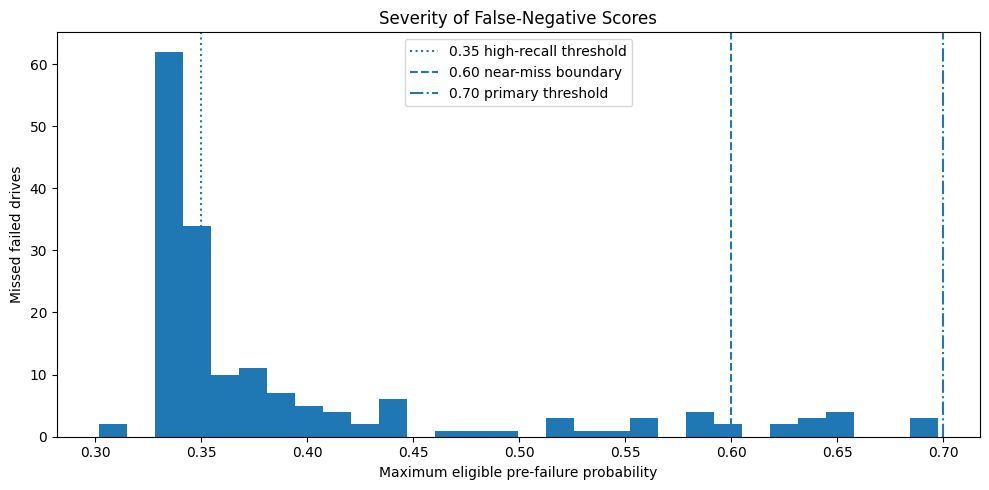

In [8]:
# ============================================================
# 8. Visualize missed-failure score severity
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(
    missed_failures["eligible_max_probability"].dropna(),
    bins=30,
)
plt.axvline(HIGH_RECALL_THRESHOLD, linestyle=":", label="0.35 high-recall threshold")
plt.axvline(0.60, linestyle="--", label="0.60 near-miss boundary")
plt.axvline(PRIMARY_THRESHOLD, linestyle="-.", label="0.70 primary threshold")
plt.xlabel("Maximum eligible pre-failure probability")
plt.ylabel("Missed failed drives")
plt.title("Severity of False-Negative Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 5. False-positive analysis

A healthy drive alerted at 0.70 may reflect a one-day score spike, a repeated but intermittent pattern, or sustained degradation.

Persistence is therefore measured in addition to maximum probability. A descriptive **possible right-censoring** flag marks drives whose last alert occurred within seven days of their final available observation. This flag does **not** prove that the drive later failed.

In [9]:
# ============================================================
# 9. Alert-persistence helper
# ============================================================

def longest_consecutive_true_run(
    dates: pd.Series,
    alert_flags: pd.Series,
) -> int:
    """Return the longest run of alerts on consecutive calendar days."""
    alert_dates = (
        pd.Series(pd.to_datetime(dates[alert_flags]))
        .dropna()
        .drop_duplicates()
        .sort_values()
    )

    if alert_dates.empty:
        return 0

    day_differences = alert_dates.diff().dt.days
    run_ids = day_differences.ne(1).cumsum()
    return int(run_ids.value_counts().max())


primary_alert_rows = eligible_oof.assign(
    alert_primary=(
        eligible_oof[PROBABILITY_COLUMN] >= PRIMARY_THRESHOLD
    )
)

persistence_records = []

for serial_number, group in primary_alert_rows.groupby(
    SERIAL_COLUMN,
    observed=True,
    sort=False,
):
    alert_mask = group["alert_primary"]

    if not alert_mask.any():
        continue

    alert_dates = group.loc[alert_mask, DATE_COLUMN]

    persistence_records.append(
        {
            SERIAL_COLUMN: serial_number,
            "first_primary_alert_date": alert_dates.min(),
            "last_primary_alert_date": alert_dates.max(),
            "primary_alert_span_days": (
                alert_dates.max() - alert_dates.min()
            ).days + 1,
            "longest_consecutive_primary_alert_run": (
                longest_consecutive_true_run(group[DATE_COLUMN], alert_mask)
            ),
        }
    )

alert_persistence = pd.DataFrame(persistence_records)

drive_summary = drive_summary.merge(
    alert_persistence,
    on=SERIAL_COLUMN,
    how="left",
)

for column in [
    "primary_alert_span_days",
    "longest_consecutive_primary_alert_run",
]:
    drive_summary[column] = drive_summary[column].fillna(0).astype(int)

drive_summary["days_from_last_alert_to_last_observation"] = (
    drive_summary["last_observation_date"]
    - drive_summary["last_primary_alert_date"]
).dt.days

print("Alert-persistence metrics added.")

Alert-persistence metrics added.


In [10]:
# ============================================================
# 10. Analyze false-alert healthy drives
# ============================================================

false_positives = drive_summary.loc[
    drive_summary["error_group"] == "false_positive"
].copy()

false_positives["alert_pattern"] = np.select(
    [
        false_positives["alert_days_primary"] == 1,
        false_positives["longest_consecutive_primary_alert_run"] >= 7,
        false_positives["alert_days_primary"] >= 3,
    ],
    [
        "single_day_spike",
        "persistent_7_plus_day_run",
        "repeated_nonpersistent_alerts",
    ],
    default="short_alert_burst",
)

false_positives["possible_right_censoring"] = (
    (false_positives["days_from_last_alert_to_last_observation"] <= 7)
    & (false_positives["overall_max_probability"] >= PRIMARY_THRESHOLD)
)

false_positive_summary = (
    false_positives.groupby("alert_pattern", observed=True)
    .agg(
        drive_count=(SERIAL_COLUMN, "nunique"),
        median_alert_days=("alert_days_primary", "median"),
        median_longest_run=("longest_consecutive_primary_alert_run", "median"),
        median_max_probability=("overall_max_probability", "median"),
        possible_censored_count=("possible_right_censoring", "sum"),
    )
    .sort_values("drive_count", ascending=False)
    .reset_index()
)

print(
    f"False-positive healthy drives at {PRIMARY_THRESHOLD:.2f}: "
    f"{len(false_positives):,}"
)
display(false_positive_summary)

display(
    false_positives[
        [
            SERIAL_COLUMN,
            "first_observation_date",
            "last_observation_date",
            "overall_max_probability",
            "alert_days_primary",
            "longest_consecutive_primary_alert_run",
            "days_from_last_alert_to_last_observation",
            "possible_right_censoring",
            "alert_pattern",
        ]
    ]
    .sort_values(
        [
            "longest_consecutive_primary_alert_run",
            "overall_max_probability",
        ],
        ascending=False,
    )
    .head(25)
)

False-positive healthy drives at 0.70: 1,986


,alert_pattern,drive_count,median_alert_days,median_longest_run,median_max_probability,possible_censored_count
0,repeated_nonpersistent_alerts,1807,23.000000,3.000000,0.989268,1671
1,single_day_spike,83,1.000000,1.000000,0.920052,65
2,short_alert_burst,76,2.000000,1.000000,0.895657,60
3,persistent_7_plus_day_run,20,29.500000,7.000000,0.985119,20


,serial_number,first_observation_date,last_observation_date,overall_max_probability,alert_days_primary,longest_consecutive_primary_alert_run,days_from_last_alert_to_last_observation,possible_right_censoring,alert_pattern
175505,Z305BFGM,2023-10-01,2023-12-31,1.000000,14,12,0.000000,True,persistent_7_plus_day_run
152164,S301JZP8,2023-10-02,2023-12-31,0.919736,34,9,0.000000,True,persistent_7_plus_day_run
130309,AAG6NTKH,2023-10-04,2023-12-16,0.780012,9,9,0.000000,True,persistent_7_plus_day_run
221843,ZJV4CKAA,2023-10-01,2023-12-30,0.999971,30,8,0.000000,True,persistent_7_plus_day_run
209077,ZHZ3QCGK,2023-10-03,2023-12-30,0.856970,31,8,0.000000,True,persistent_7_plus_day_run
263366,ZLW0EGFT,2023-10-03,2023-12-31,0.801711,29,8,7.000000,True,persistent_7_plus_day_run
235271,ZL23XRYJ,2023-10-07,2023-12-28,1.000000,20,7,0.000000,True,persistent_7_plus_day_run
273809,ZLW18MG9,2023-10-03,2023-12-29,1.000000,35,7,0.000000,True,persistent_7_plus_day_run
268780,ZLW0H351,2023-10-01,2023-12-29,1.000000,32,7,0.000000,True,persistent_7_plus_day_run
194463,ZA15RBKL,2023-10-02,2023-12-31,1.000000,35,7,0.000000,True,persistent_7_plus_day_run


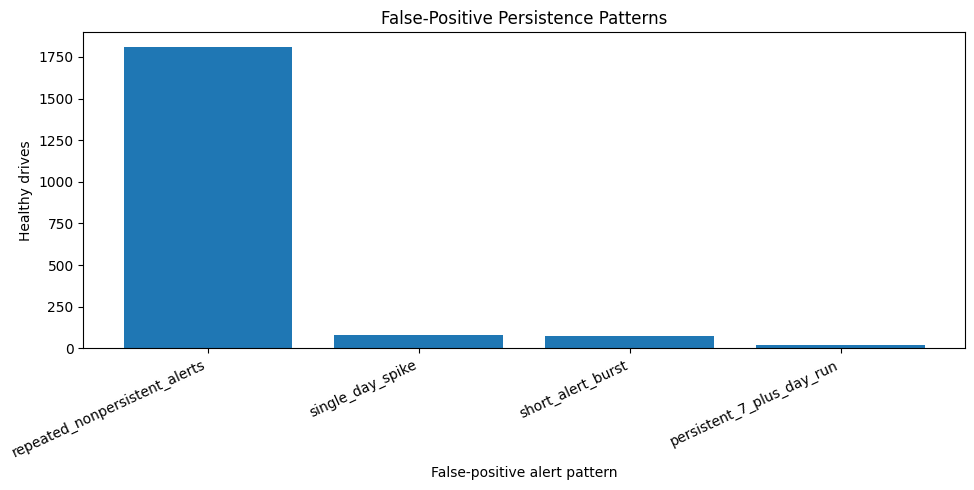

In [11]:
# ============================================================
# 11. Visualize false-positive persistence
# ============================================================

pattern_counts = (
    false_positives["alert_pattern"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(pattern_counts.index, pattern_counts.values)
plt.ylabel("Healthy drives")
plt.xlabel("False-positive alert pattern")
plt.title("False-Positive Persistence Patterns")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 6. Load only the SMART columns needed for diagnosis

`df_cleaned.parquet` is intentionally **not** loaded with every column.

The notebook first inspects the Parquet schema using PyArrow metadata, then reads only the three selected SMART attributes plus identifiers and any available drive metadata. This avoids the expensive historical pattern of loading the full large dataset merely to discover its column names.

In [12]:
# ============================================================
# 12. Load cleaned SMART data efficiently
# ============================================================

cleaned_dataset = ds.dataset(str(CLEANED_DATA_PATH), format="parquet")
available_cleaned_columns = cleaned_dataset.schema.names

required_cleaned_columns = {
    SERIAL_COLUMN,
    DATE_COLUMN,
    *FEATURE_COLUMNS,
}

missing_cleaned_columns = required_cleaned_columns.difference(
    available_cleaned_columns
)
if missing_cleaned_columns:
    raise ValueError(
        "Cleaned dataset is missing required columns: "
        f"{sorted(missing_cleaned_columns)}"
    )

cleaned_columns = [
    SERIAL_COLUMN,
    DATE_COLUMN,
    TARGET_COLUMN,
    *FEATURE_COLUMNS,
    *[
        column
        for column in OPTIONAL_METADATA_COLUMNS
        if column in available_cleaned_columns
    ],
]

cleaned_columns = list(
    dict.fromkeys(
        column
        for column in cleaned_columns
        if column in available_cleaned_columns
    )
)

print("Reading only these columns:")
print(cleaned_columns)

cleaned = pd.read_parquet(
    CLEANED_DATA_PATH,
    columns=cleaned_columns,
)

cleaned[DATE_COLUMN] = pd.to_datetime(
    cleaned[DATE_COLUMN], errors="coerce"
)

for feature in FEATURE_COLUMNS:
    cleaned[feature] = pd.to_numeric(
        cleaned[feature], errors="coerce"
    )

cleaned = cleaned.dropna(
    subset=[SERIAL_COLUMN, DATE_COLUMN]
).copy()

duplicate_drive_dates = int(
    cleaned.duplicated([SERIAL_COLUMN, DATE_COLUMN]).sum()
)

if duplicate_drive_dates:
    print(
        f"Collapsing {duplicate_drive_dates:,} duplicate drive-date rows."
    )

    aggregation_map = {
        feature: "max" for feature in FEATURE_COLUMNS
    }

    if TARGET_COLUMN in cleaned.columns:
        aggregation_map[TARGET_COLUMN] = "max"

    for metadata_column in OPTIONAL_METADATA_COLUMNS:
        if metadata_column in cleaned.columns:
            aggregation_map[metadata_column] = "first"

    cleaned = (
        cleaned.groupby(
            [SERIAL_COLUMN, DATE_COLUMN],
            observed=True,
            as_index=False,
        )
        .agg(aggregation_map)
    )

print(f"Cleaned SMART rows loaded: {len(cleaned):,}")
print(f"Columns loaded: {cleaned.columns.tolist()}")

Reading only these columns:
['serial_number', 'date', 'failure', 'smart_5_raw', 'smart_197_raw', 'smart_198_raw', 'model', 'capacity_bytes']
Cleaned SMART rows loaded: 24,790,999
Columns loaded: ['serial_number', 'date', 'failure', 'smart_5_raw', 'smart_197_raw', 'smart_198_raw', 'model', 'capacity_bytes']


In [13]:
# ============================================================
# 13. Merge OOF predictions with SMART features
# ============================================================

analysis_rows = oof.merge(
    cleaned,
    on=[SERIAL_COLUMN, DATE_COLUMN],
    how="left",
    validate="many_to_one",
    suffixes=("_oof", "_cleaned"),
)

feature_match_rate = (
    analysis_rows[FEATURE_COLUMNS]
    .notna()
    .all(axis=1)
    .mean()
)

print(f"Rows after merge: {len(analysis_rows):,}")
print(f"Complete SMART-feature match rate: {feature_match_rate:.2%}")

if feature_match_rate < 0.95:
    warnings.warn(
        "Fewer than 95% of OOF rows matched complete SMART features. "
        "Confirm that the OOF and cleaned files came from the same sampled dataset."
    )

display(analysis_rows.head())

Rows after merge: 7,437,300
Complete SMART-feature match rate: 96.83%


,fold,serial_number,date,y_true,y_prob,failure_date,is_eligible_pre_failure,failure,smart_5_raw,smart_197_raw,smart_198_raw,model,capacity_bytes
0,0,000a43e7dee60010,2023-10-02,0,0.334120,NaT,True,0,NaN,NaN,NaN,DELLBOSS VD,480036847616
1,0,000a43e7dee60010,2023-10-10,0,0.334120,NaT,True,0,NaN,NaN,NaN,DELLBOSS VD,480036847616
2,0,000a43e7dee60010,2023-10-13,0,0.334120,NaT,True,0,NaN,NaN,NaN,DELLBOSS VD,480036847616
3,0,000a43e7dee60010,2023-10-16,0,0.334120,NaT,True,0,NaN,NaN,NaN,DELLBOSS VD,480036847616
4,0,000a43e7dee60010,2023-10-22,0,0.334120,NaT,True,0,NaN,NaN,NaN,DELLBOSS VD,480036847616


## 7. Feature patterns by drive-level error group

Raw SMART attributes are highly skewed, so the analysis reports robust distribution summaries and the rate at which each attribute is non-zero.

The comparison is descriptive. It is used to understand what information the baseline was or was not seeing, not to claim causal relationships.

,error_group,feature,row_count,median,p90,p99,maximum,nonzero_row_rate
0,false_negative,smart_5_raw,2124,0.000000,22.000000,661.190000,"2,160.000000",0.241055
1,false_negative,smart_197_raw,2057,0.000000,3.000000,11.000000,14.000000,0.254254
2,false_negative,smart_198_raw,2121,0.000000,0.000000,20.000000,22.000000,0.098067
3,false_positive,smart_5_raw,49777,15.000000,"11,944.000000","54,320.000000","65,528.000000",0.596099
4,false_positive,smart_197_raw,49495,12.000000,96.000000,"1,272.000000","26,496.000000",0.613739
5,false_positive,smart_198_raw,49777,0.000000,68.000000,776.000000,"26,496.000000",0.466039
6,true_negative,smart_5_raw,7316620,0.000000,0.000000,24.000000,"2,845.000000",0.029296
7,true_negative,smart_197_raw,7148006,0.000000,0.000000,0.000000,14.000000,0.006741
8,true_negative,smart_198_raw,7309947,0.000000,0.000000,0.000000,492.000000,0.004372
9,true_positive,smart_5_raw,2002,24.000000,"13,064.800000","48,578.560000","65,520.000000",0.655844


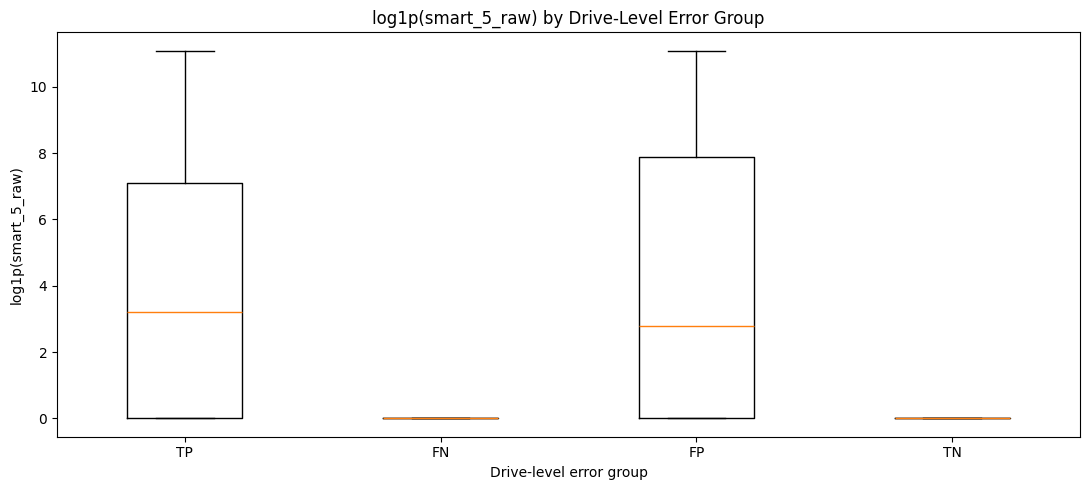

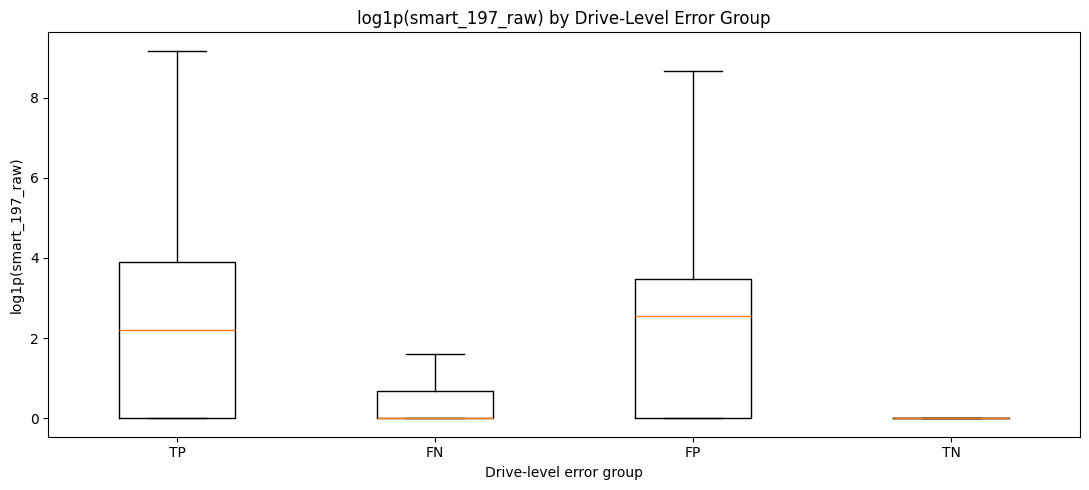

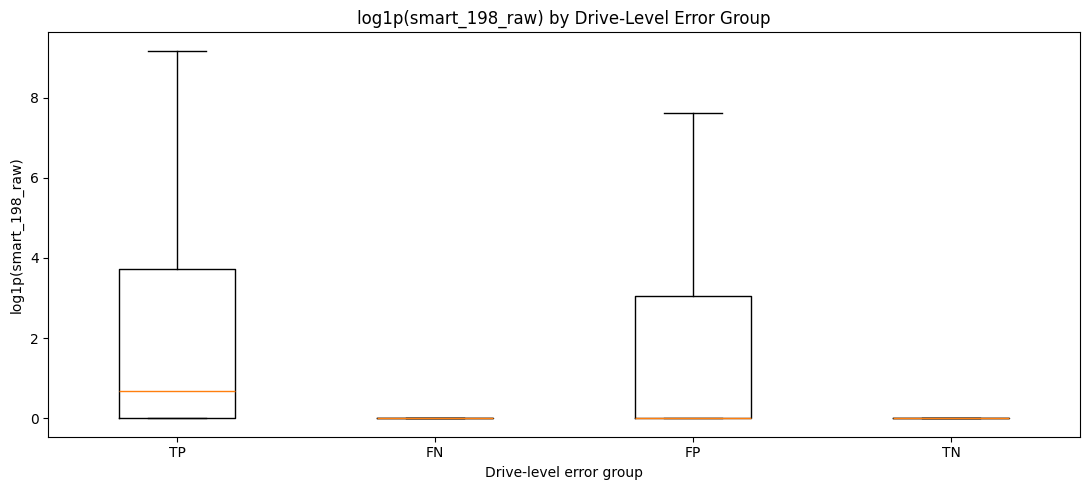

In [14]:
# ============================================================
# 14. Feature summaries by drive error group
# ============================================================

analysis_rows = analysis_rows.merge(
    drive_summary[
        [SERIAL_COLUMN, "error_group", "failure_detection_tier"]
    ],
    on=SERIAL_COLUMN,
    how="left",
    validate="many_to_one",
)

feature_summary_records = []

for error_group, group in analysis_rows.groupby(
    "error_group",
    observed=True,
):
    for feature in FEATURE_COLUMNS:
        values = group[feature].dropna()

        feature_summary_records.append(
            {
                "error_group": error_group,
                "feature": feature,
                "row_count": len(values),
                "median": values.median(),
                "p90": values.quantile(0.90),
                "p99": values.quantile(0.99),
                "maximum": values.max(),
                "nonzero_row_rate": (values > 0).mean(),
            }
        )

feature_group_summary = pd.DataFrame(feature_summary_records)

display(feature_group_summary)

for feature in FEATURE_COLUMNS:
    plot_data = []

    for error_group in [
        "true_positive",
        "false_negative",
        "false_positive",
        "true_negative",
    ]:
        values = analysis_rows.loc[
            analysis_rows["error_group"] == error_group,
            feature,
        ].dropna()

        plot_data.append(np.log1p(values))

    plt.figure(figsize=(11, 5))
    plt.boxplot(
        plot_data,
        tick_labels=["TP", "FN", "FP", "TN"],
        showfliers=False,
    )
    plt.title(f"log1p({feature}) by Drive-Level Error Group")
    plt.xlabel("Drive-level error group")
    plt.ylabel(f"log1p({feature})")
    plt.tight_layout()
    plt.show()

## 8. Optional drive-model concentration analysis

If `model` metadata is available, calculate failure miss rates and healthy-drive alert rates by hardware model. This can reveal whether a single global relationship between the three SMART attributes and failure risk behaves unevenly across device populations.

Rates for models with very few failed drives should be interpreted cautiously.

In [15]:
# ============================================================
# 15. Optional model / manufacturer concentration analysis
# ============================================================

metadata_columns_present = [
    column
    for column in OPTIONAL_METADATA_COLUMNS
    if column in analysis_rows.columns
]

model_error_counts = None

if not metadata_columns_present:
    print(
        "No optional model/manufacturer metadata columns were found. "
        "Skipping concentration analysis."
    )
else:
    drive_metadata = (
        analysis_rows[
            [SERIAL_COLUMN, *metadata_columns_present]
        ]
        .drop_duplicates(SERIAL_COLUMN)
    )

    error_with_metadata = drive_summary.merge(
        drive_metadata,
        on=SERIAL_COLUMN,
        how="left",
    )

    if "model" in error_with_metadata.columns:
        model_error_counts = (
            error_with_metadata.groupby(
                ["model", "error_group"],
                observed=True,
            )
            .size()
            .unstack(fill_value=0)
        )

        for column in [
            "true_positive",
            "false_negative",
            "false_positive",
            "true_negative",
        ]:
            if column not in model_error_counts.columns:
                model_error_counts[column] = 0

        model_error_counts["failed_total"] = (
            model_error_counts["true_positive"]
            + model_error_counts["false_negative"]
        )
        model_error_counts["healthy_total"] = (
            model_error_counts["false_positive"]
            + model_error_counts["true_negative"]
        )

        model_error_counts["failed_drive_miss_rate"] = np.where(
            model_error_counts["failed_total"] > 0,
            (
                model_error_counts["false_negative"]
                / model_error_counts["failed_total"]
            ),
            np.nan,
        )

        model_error_counts["healthy_drive_alert_rate"] = np.where(
            model_error_counts["healthy_total"] > 0,
            (
                model_error_counts["false_positive"]
                / model_error_counts["healthy_total"]
            ),
            np.nan,
        )

        model_error_counts = model_error_counts.reset_index()

        print("Models with the most missed failed drives:")
        display(
            model_error_counts.sort_values(
                ["false_negative", "failed_total"],
                ascending=False,
            ).head(20)
        )

        print("Models with the most false-positive healthy drives:")
        display(
            model_error_counts.sort_values(
                ["false_positive", "healthy_total"],
                ascending=False,
            ).head(20)
        )
    else:
        print("No model column available; model-level analysis skipped.")

Models with the most missed failed drives:


error_group,model,false_negative,false_positive,true_negative,true_positive,failed_total,healthy_total,failed_drive_miss_rate,healthy_drive_alert_rate
64,TOSHIBA MG08ACA16TA,31,25,33725,5,36,33750,0.861111,0.000741
62,TOSHIBA MG07ACA14TA,28,1,38092,1,29,38093,0.965517,0.000026
24,ST12000NM0008,25,186,19341,26,51,19527,0.490196,0.009525
10,HGST HUH721212ALN604,20,218,10392,20,40,10610,0.500000,0.020547
9,HGST HUH721212ALE604,10,134,13088,7,17,13222,0.588235,0.010135
26,ST12000NM001G,9,76,13069,2,11,13145,0.818182,0.005782
34,ST16000NM001G,8,75,27567,8,16,27642,0.500000,0.002713
38,ST4000DM000,7,250,15698,19,26,15948,0.269231,0.015676
47,ST8000DM002,3,131,9159,7,10,9290,0.300000,0.014101
78,WDC WUH721816ALE6L4,3,12,21604,2,5,21616,0.600000,0.000555


Models with the most false-positive healthy drives:


error_group,model,false_negative,false_positive,true_negative,true_positive,failed_total,healthy_total,failed_drive_miss_rate,healthy_drive_alert_rate
50,ST8000NM0055,2,272,13718,14,16,13990,0.125000,0.019442
38,ST4000DM000,7,250,15698,19,26,15948,0.269231,0.015676
10,HGST HUH721212ALN604,20,218,10392,20,40,10610,0.500000,0.020547
24,ST12000NM0008,25,186,19341,26,51,19527,0.490196,0.009525
31,ST14000NM001G,1,138,10627,15,16,10765,0.062500,0.012819
9,HGST HUH721212ALE604,10,134,13088,7,17,13222,0.588235,0.010135
47,ST8000DM002,3,131,9159,7,10,9290,0.300000,0.014101
21,ST10000NM0086,0,88,1020,5,5,1108,0.000000,0.079422
23,ST12000NM0007,1,87,1093,4,5,1180,0.200000,0.073729
26,ST12000NM001G,9,76,13069,2,11,13145,0.818182,0.005782


## 9. Representative drive trajectories

A small set of representative drives is selected automatically from each confusion-matrix group.

The plots place the model probability alongside the three SMART histories so that score behavior can be compared with the raw degradation signals.

In [16]:
# ============================================================
# 16. Select representative drives
# ============================================================

def take_serials(frame, sort_columns, ascending, n):
    if frame.empty:
        return []

    return (
        frame.sort_values(sort_columns, ascending=ascending)
        [SERIAL_COLUMN]
        .head(n)
        .tolist()
    )


representative_serials = {
    "true_positive": take_serials(
        drive_summary.loc[
            drive_summary["error_group"] == "true_positive"
        ],
        ["lead_time_days_primary", "eligible_max_probability"],
        [False, False],
        N_EXAMPLES_PER_GROUP,
    ),
    "false_negative": take_serials(
        drive_summary.loc[
            drive_summary["error_group"] == "false_negative"
        ],
        ["eligible_max_probability", "eligible_observed_days"],
        [False, True],
        N_EXAMPLES_PER_GROUP,
    ),
    "false_positive": take_serials(
        drive_summary.loc[
            drive_summary["error_group"] == "false_positive"
        ],
        [
            "longest_consecutive_primary_alert_run",
            "overall_max_probability",
        ],
        [False, False],
        N_EXAMPLES_PER_GROUP,
    ),
    "true_negative": take_serials(
        drive_summary.loc[
            drive_summary["error_group"] == "true_negative"
        ],
        ["overall_max_probability"],
        [False],
        N_EXAMPLES_PER_GROUP,
    ),
}

representative_records = []

for error_group, serial_numbers in representative_serials.items():
    for rank, serial_number in enumerate(serial_numbers, start=1):
        representative_records.append(
            {
                "error_group": error_group,
                "selection_rank": rank,
                SERIAL_COLUMN: serial_number,
            }
        )

representative_cases = pd.DataFrame(representative_records)

display(representative_cases)

,error_group,selection_rank,serial_number
0,true_positive,1,ZA21C0JJ
1,true_positive,2,8CGLBLKG
2,true_positive,3,ZLW18EHG
3,false_negative,1,S2ZYJ9GGB01081
4,false_negative,2,WD-WXQ1AA541HX5
5,false_negative,3,8CH384ME
6,false_positive,1,Z305BFGM
7,false_positive,2,S301JZP8
8,false_positive,3,AAG6NTKH
9,true_negative,1,ZA1818SG


### True Positive examples

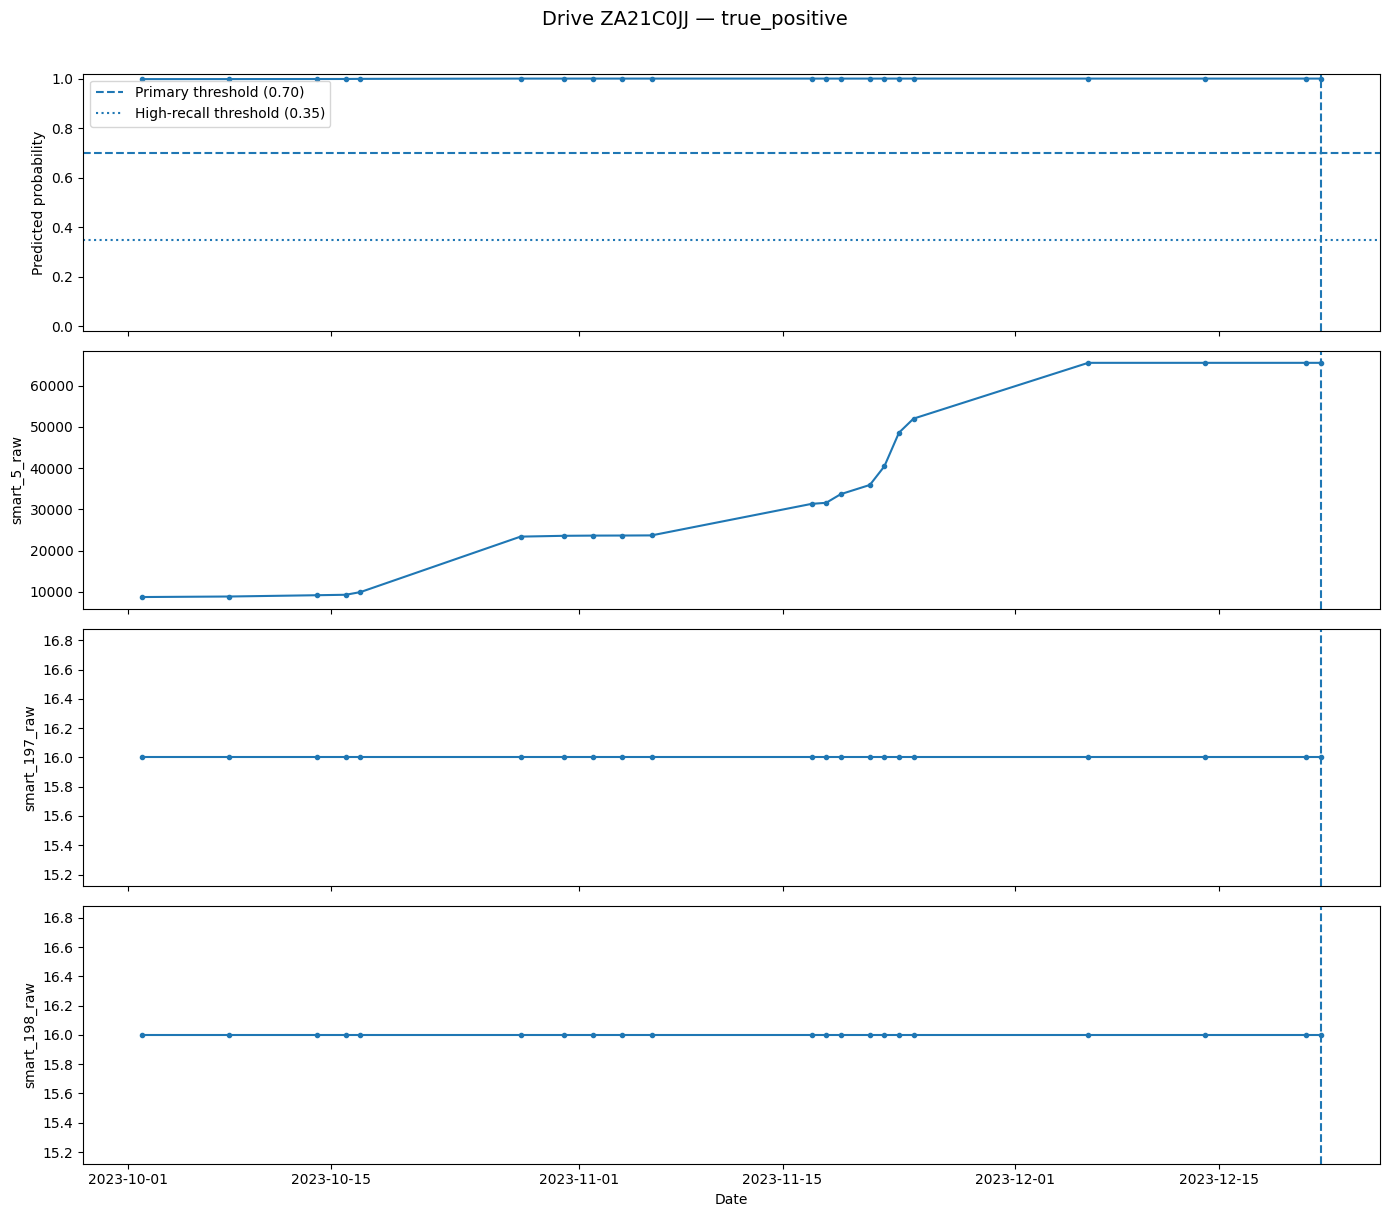

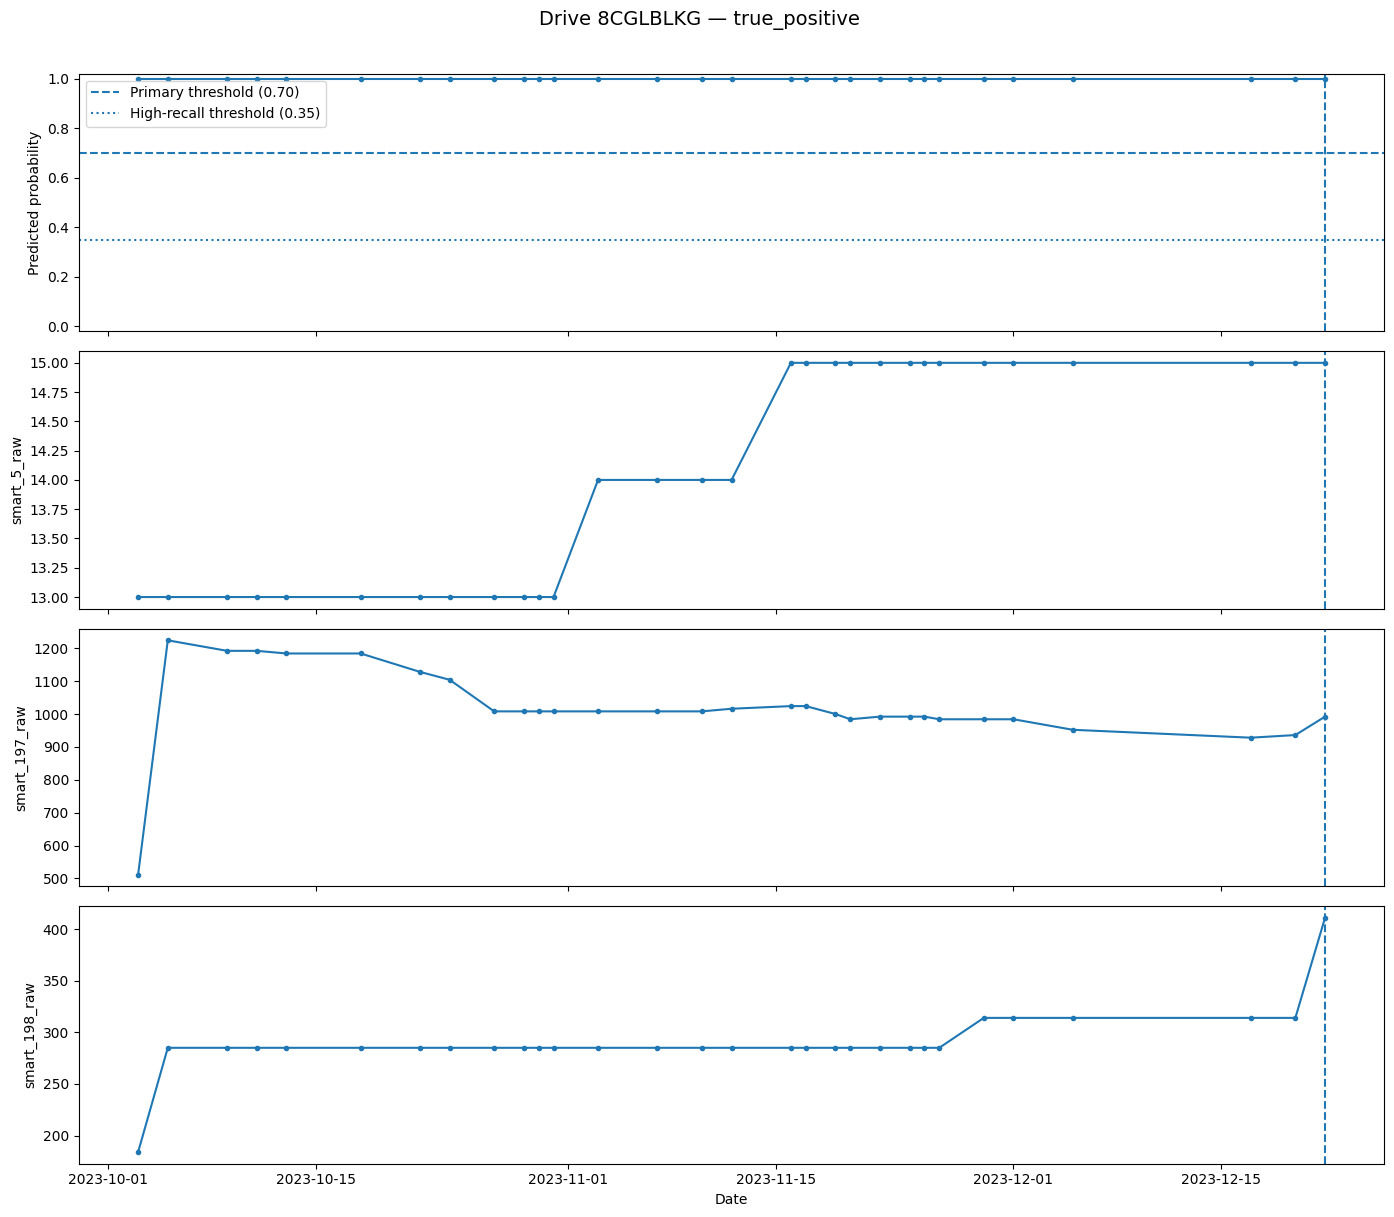

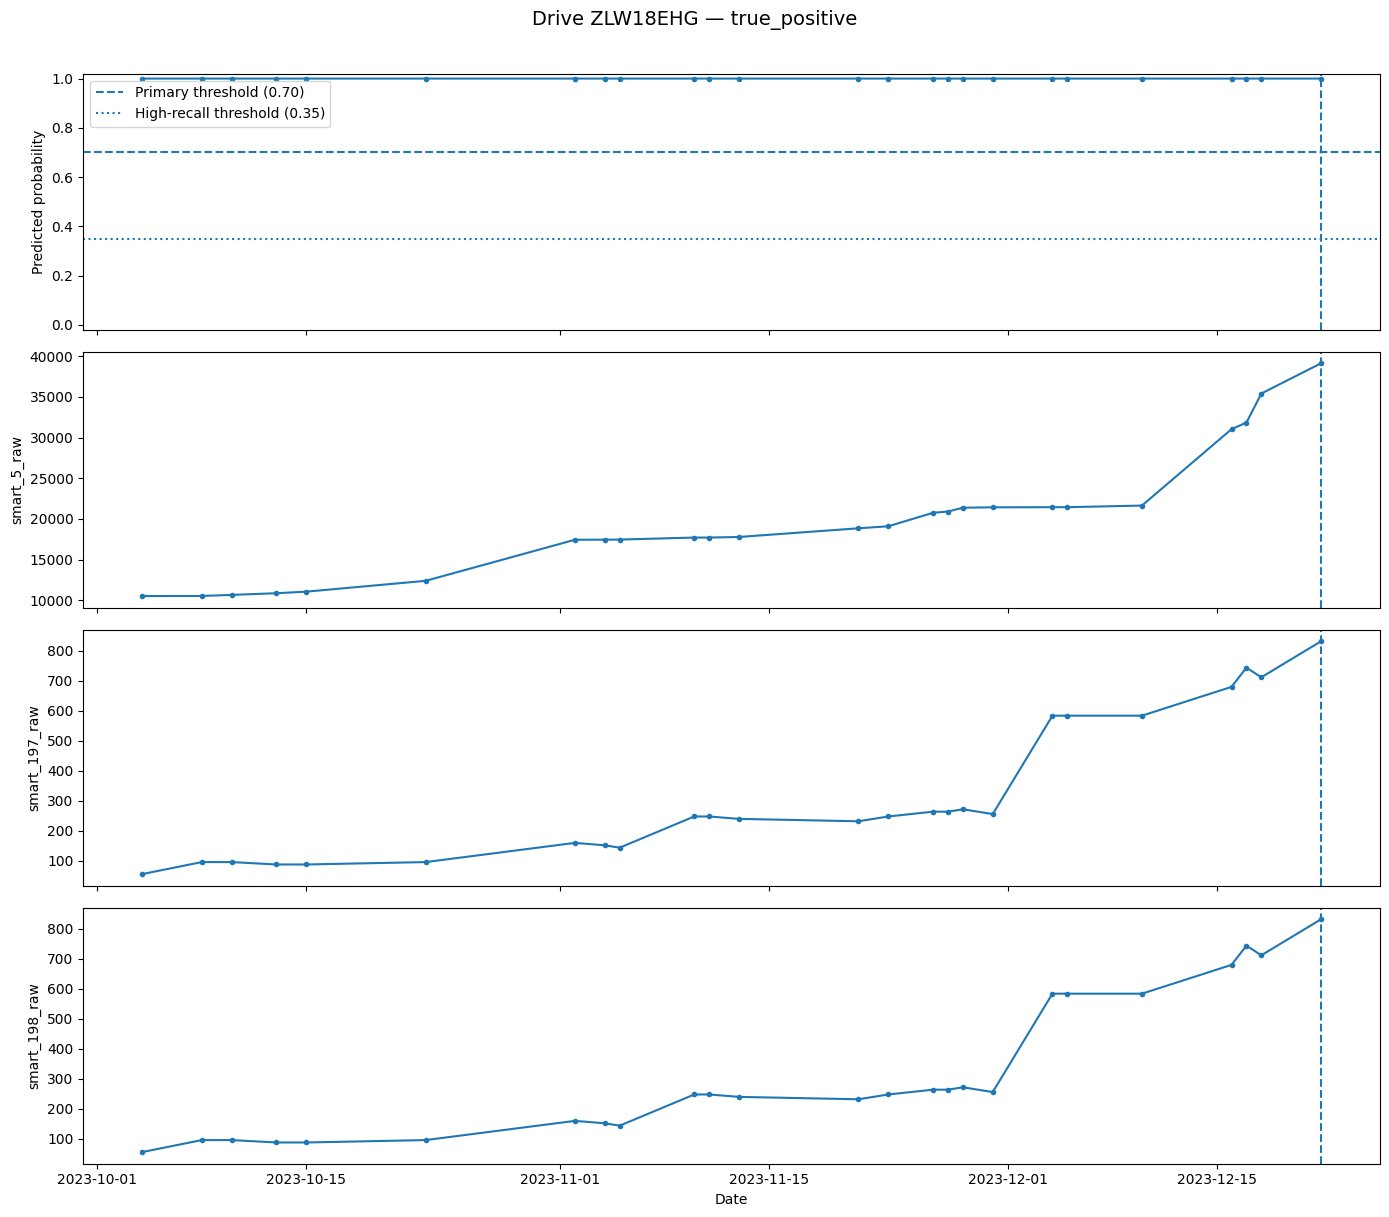

### False Negative examples

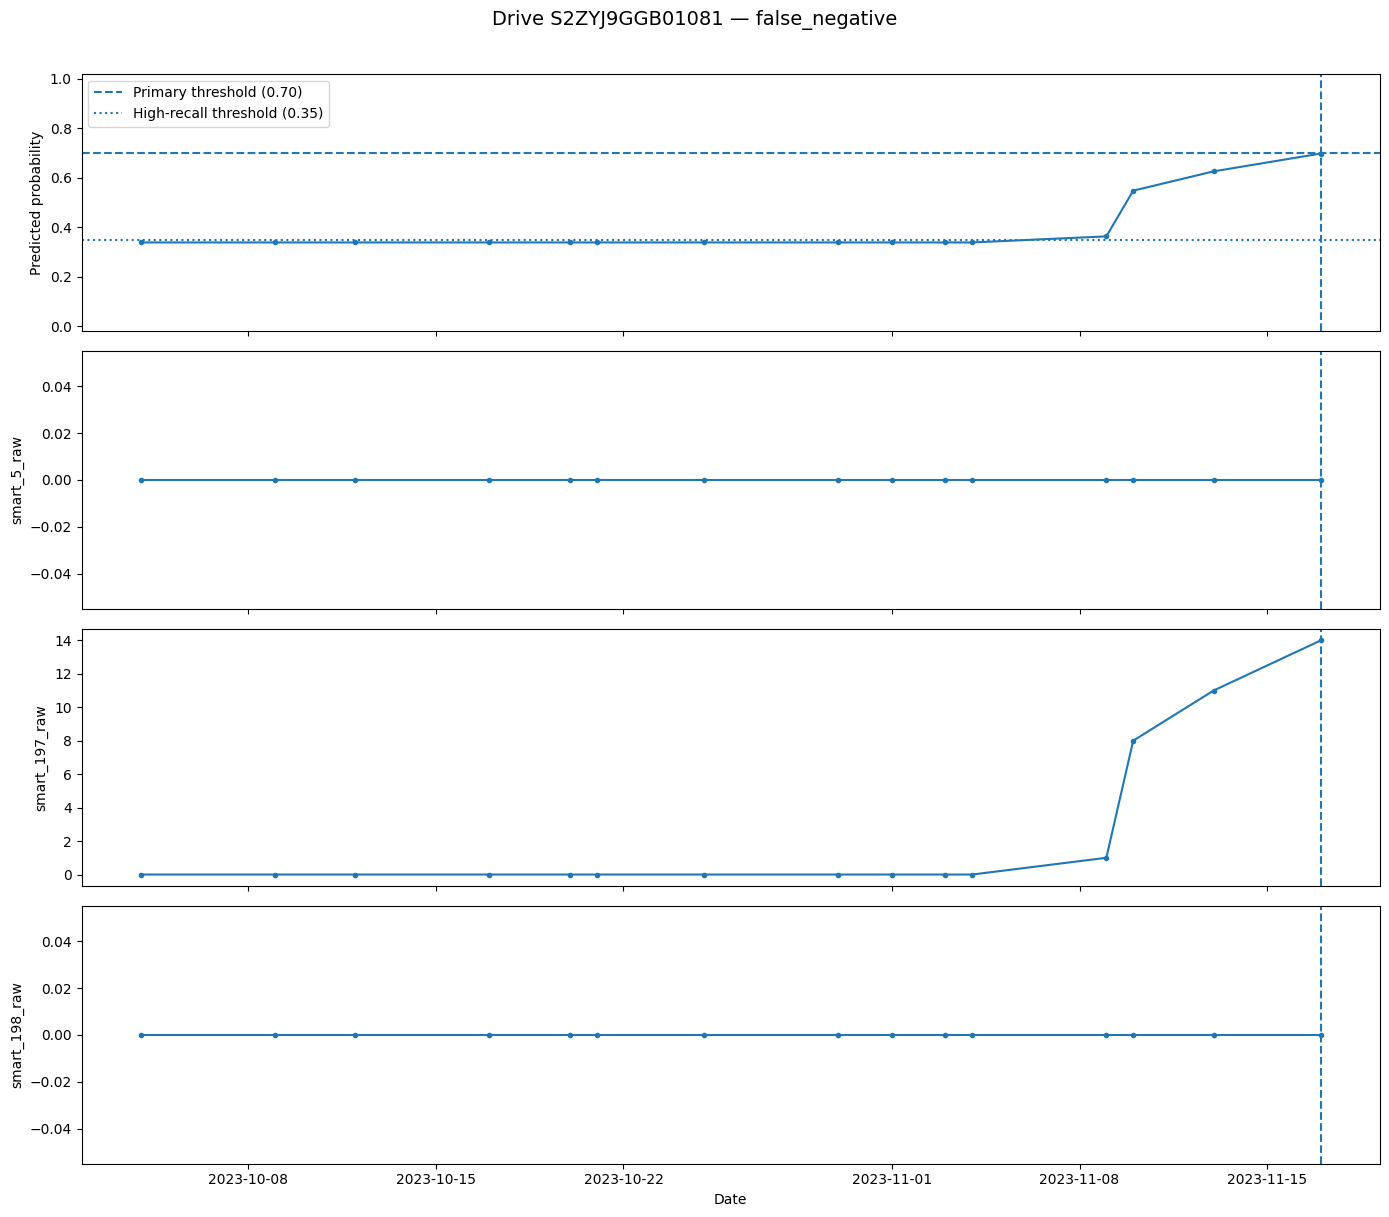

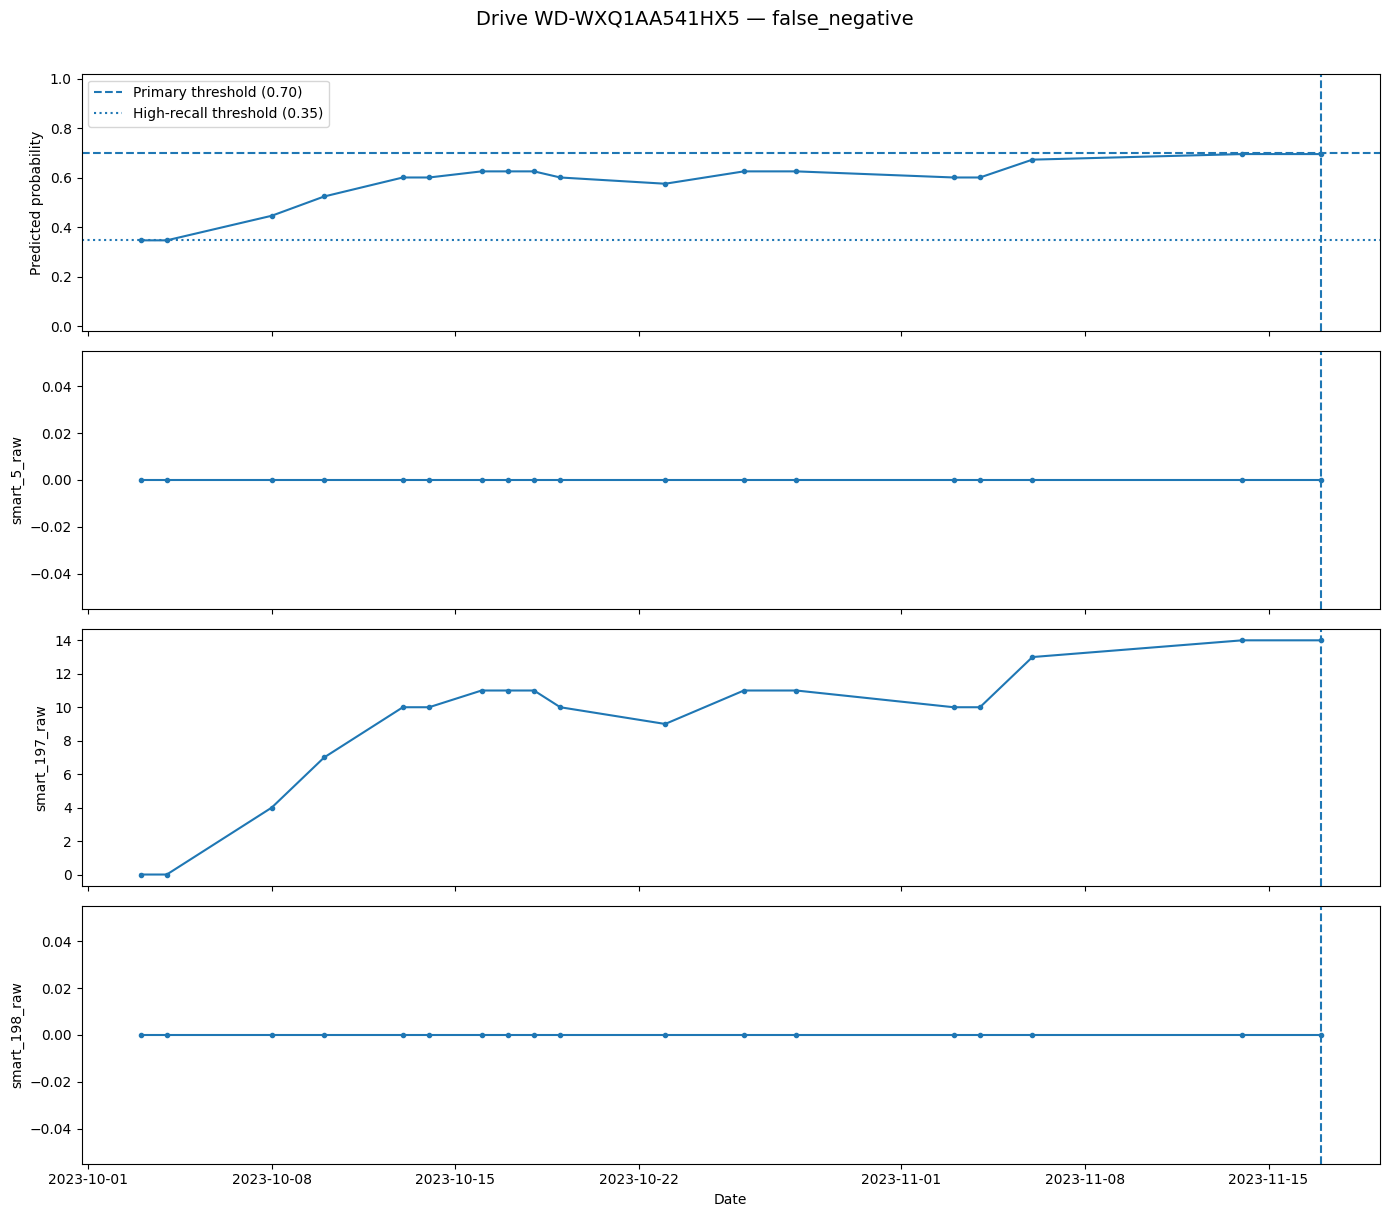

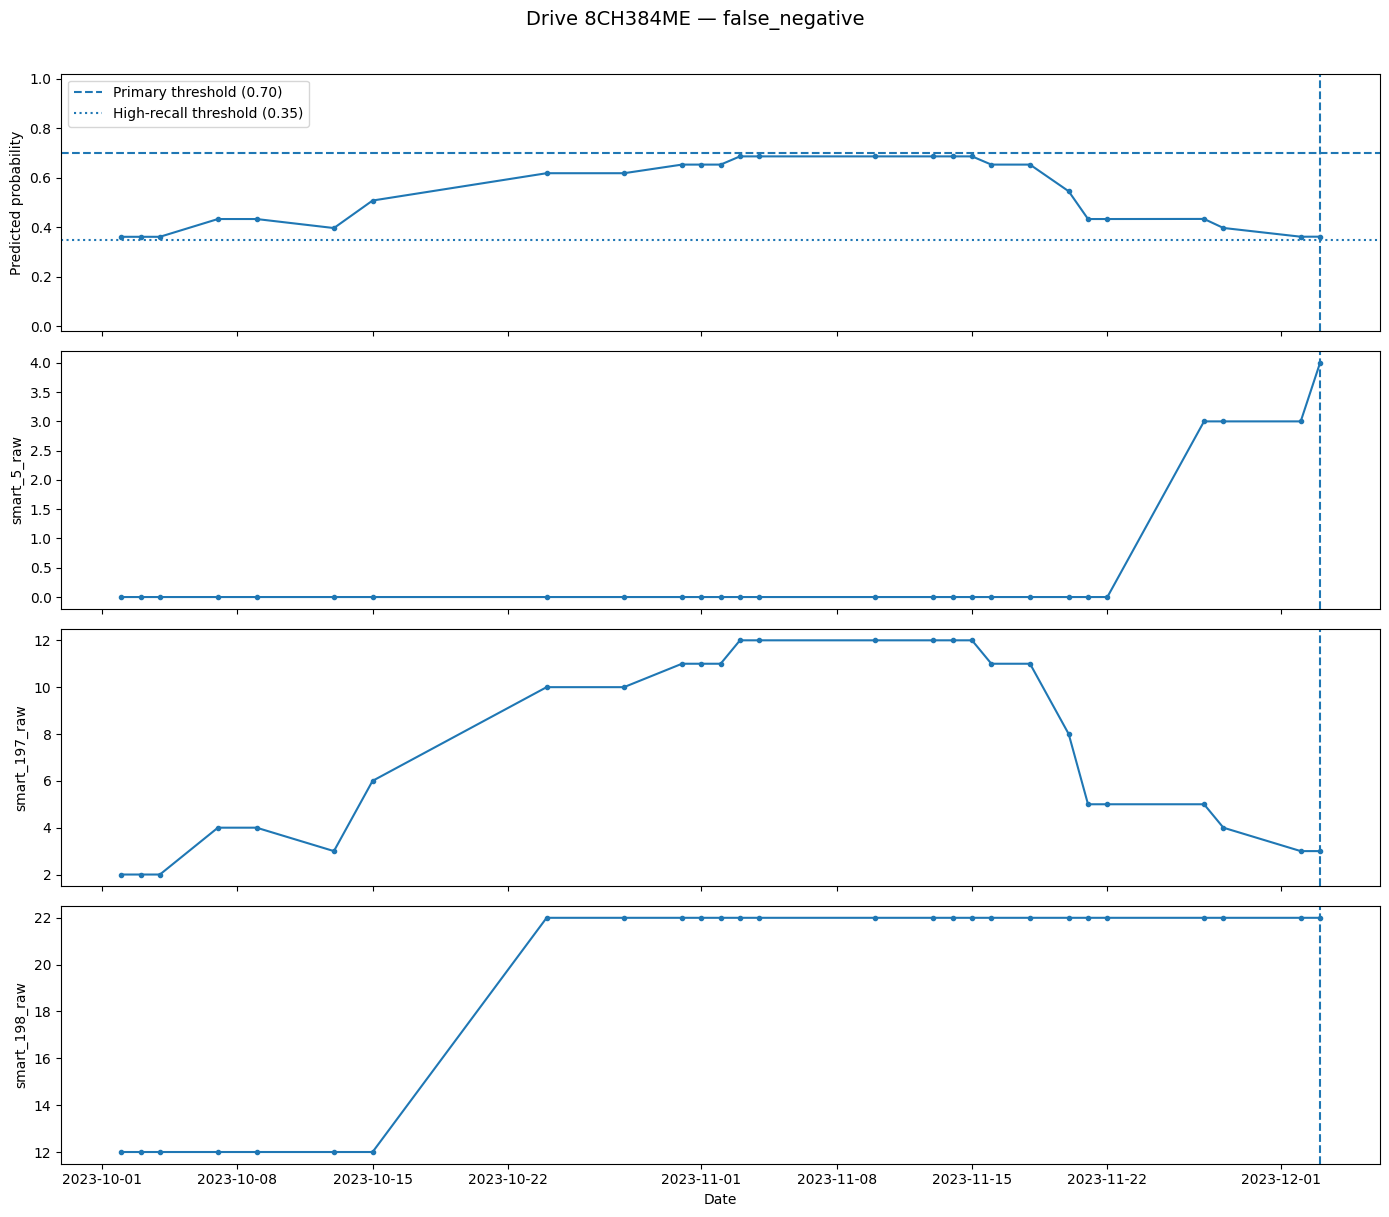

### False Positive examples

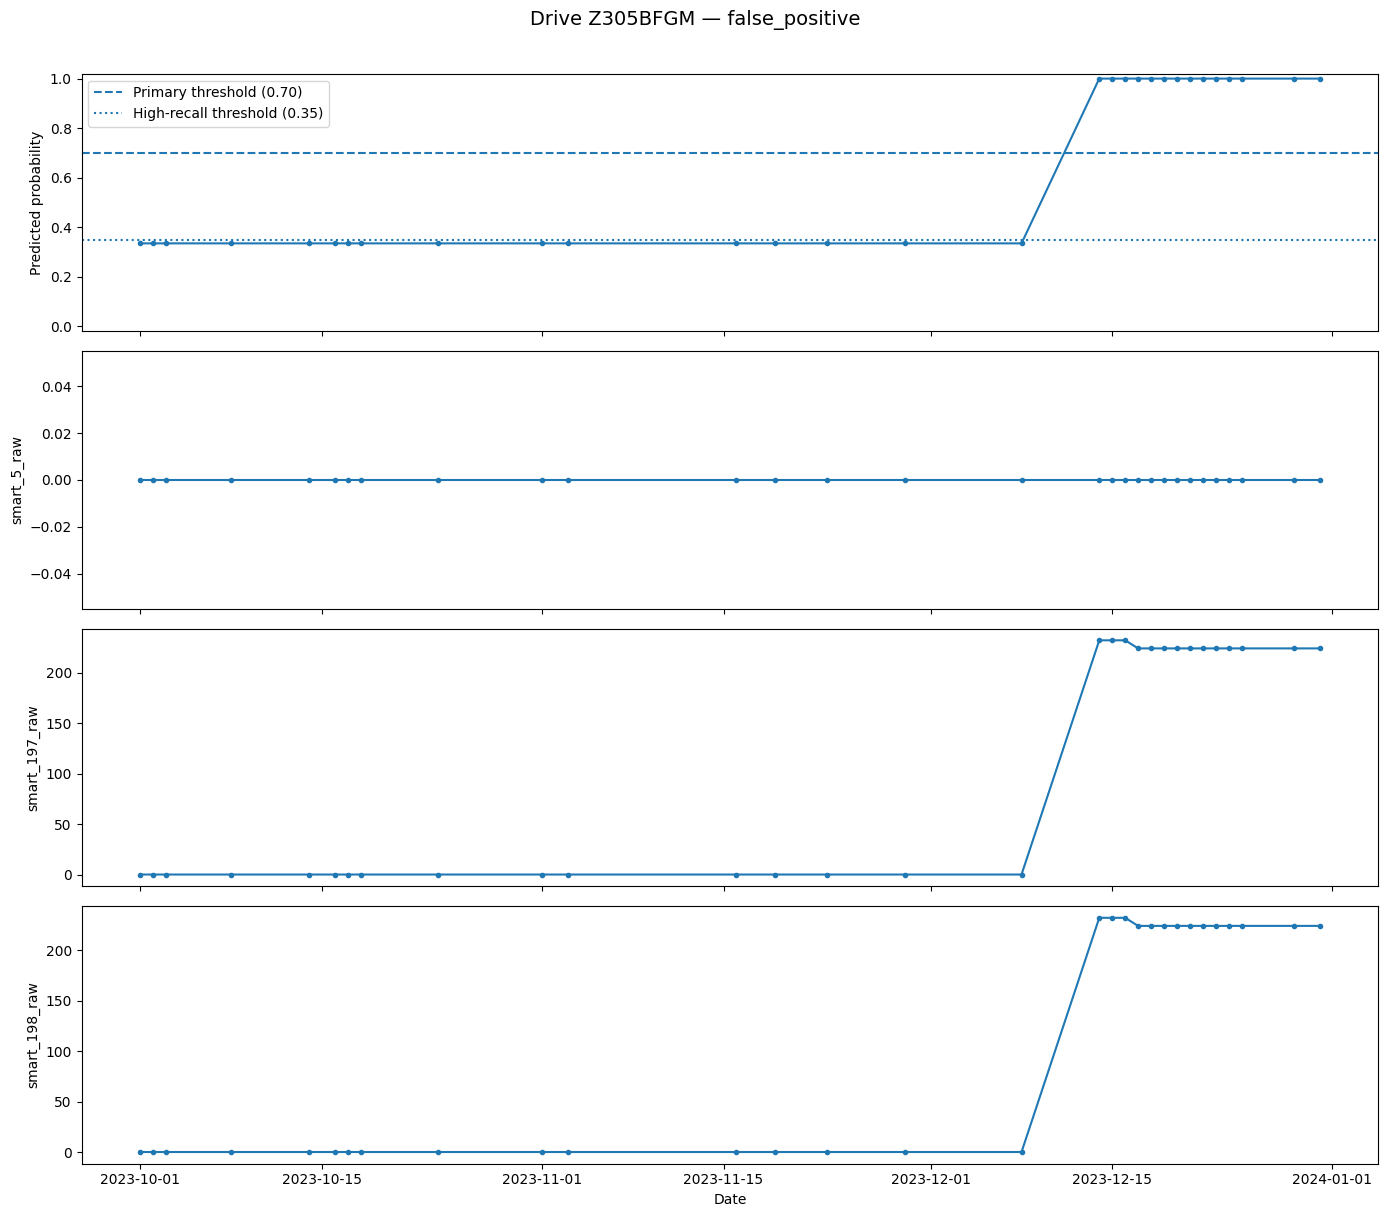

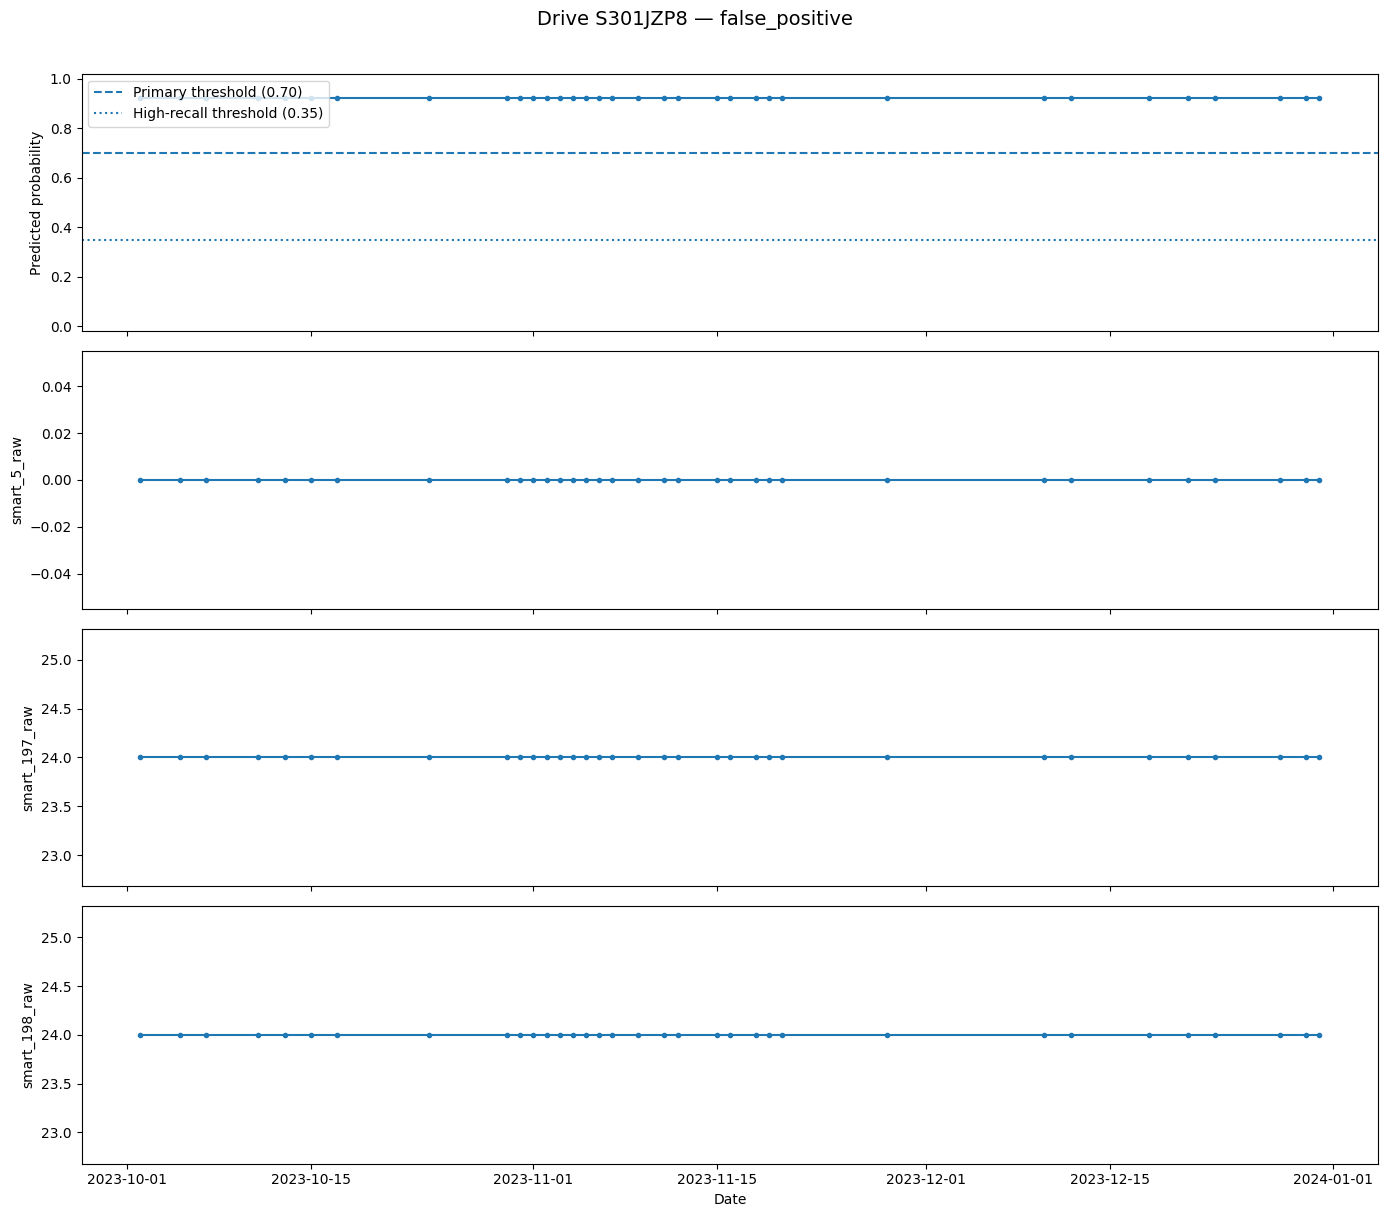

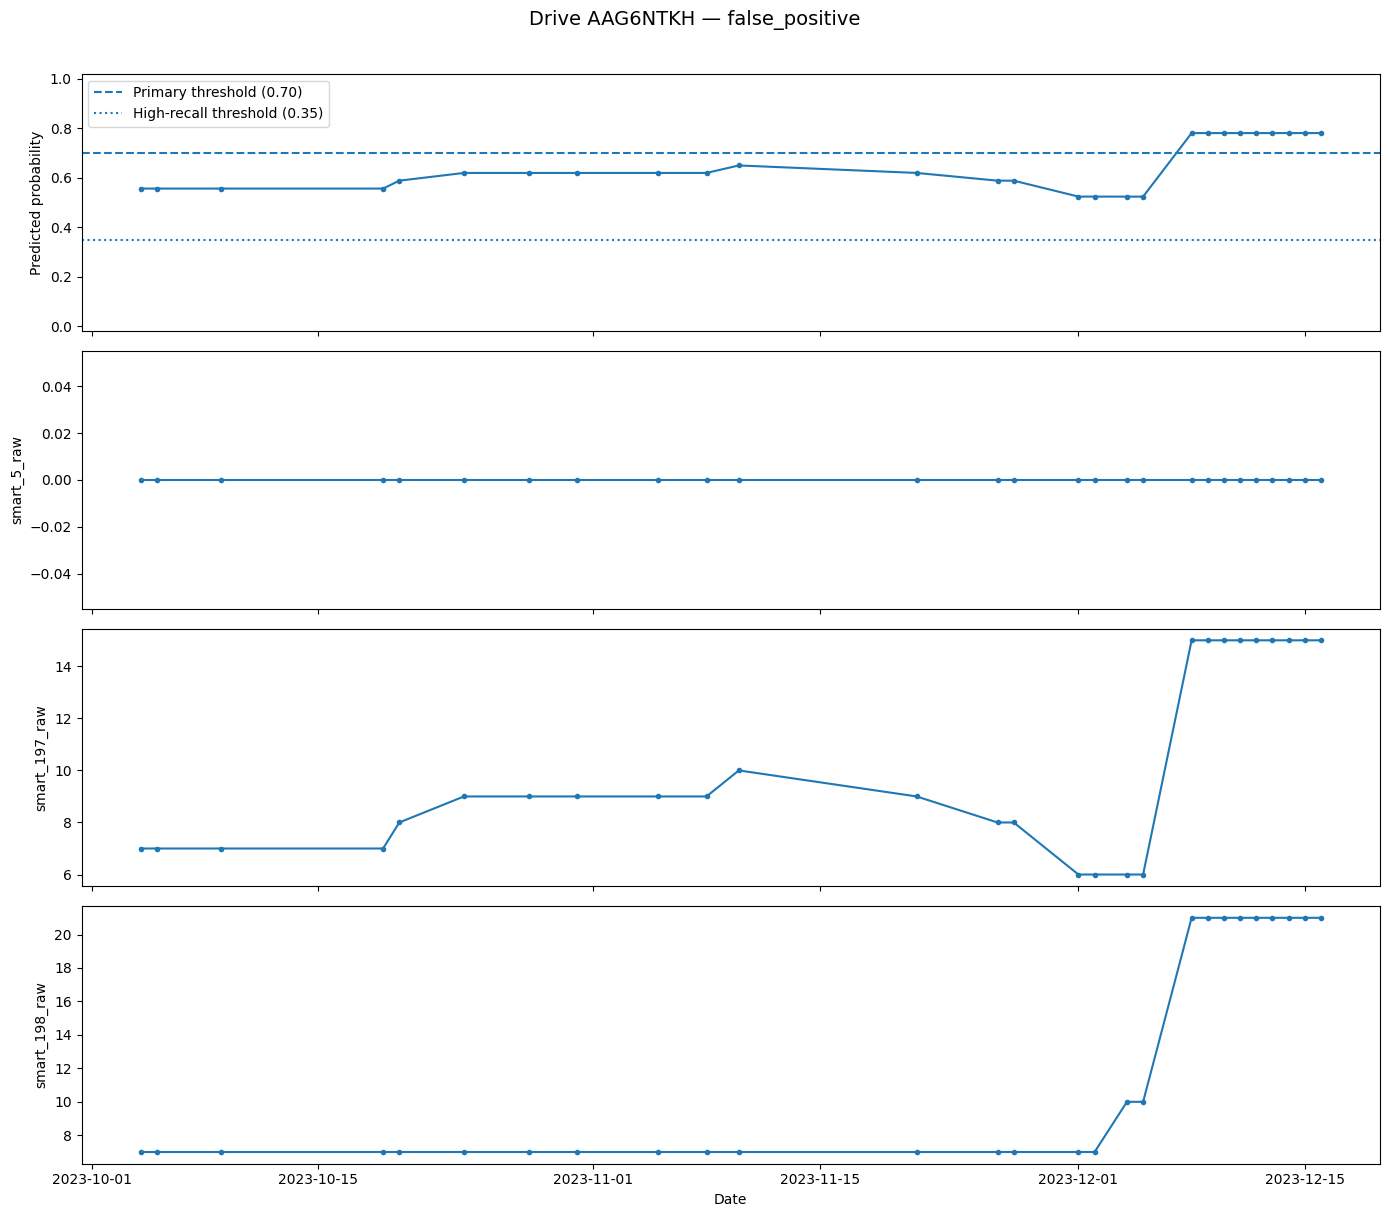

### True Negative examples

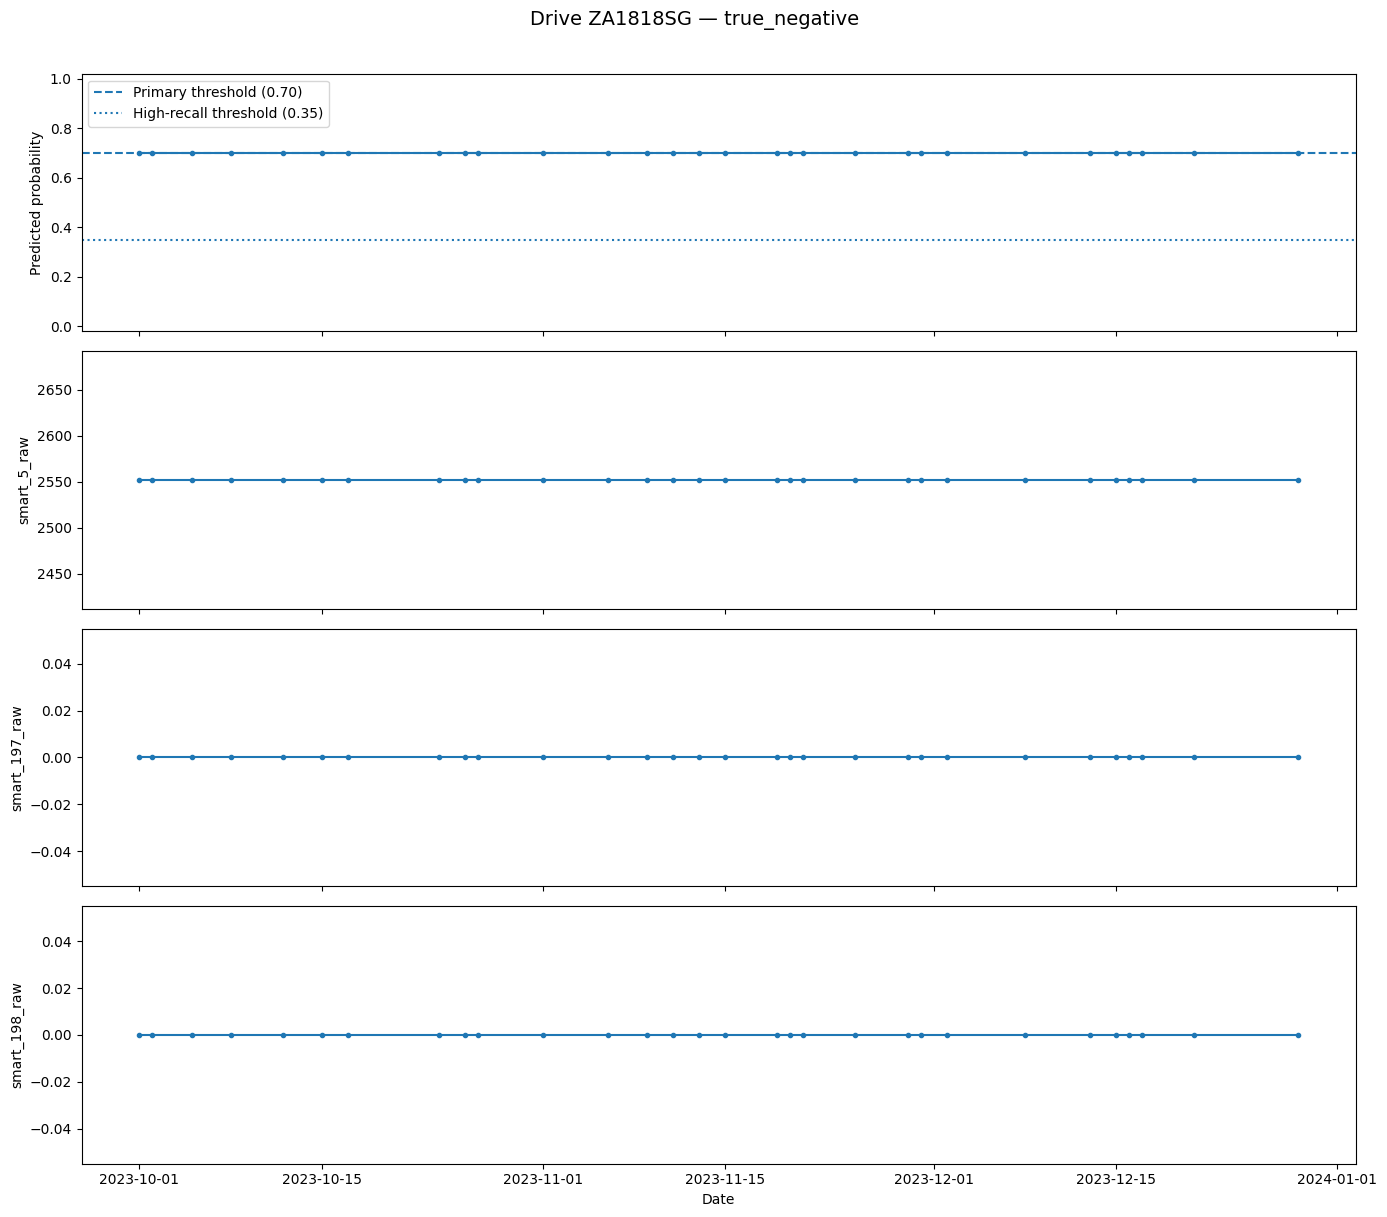

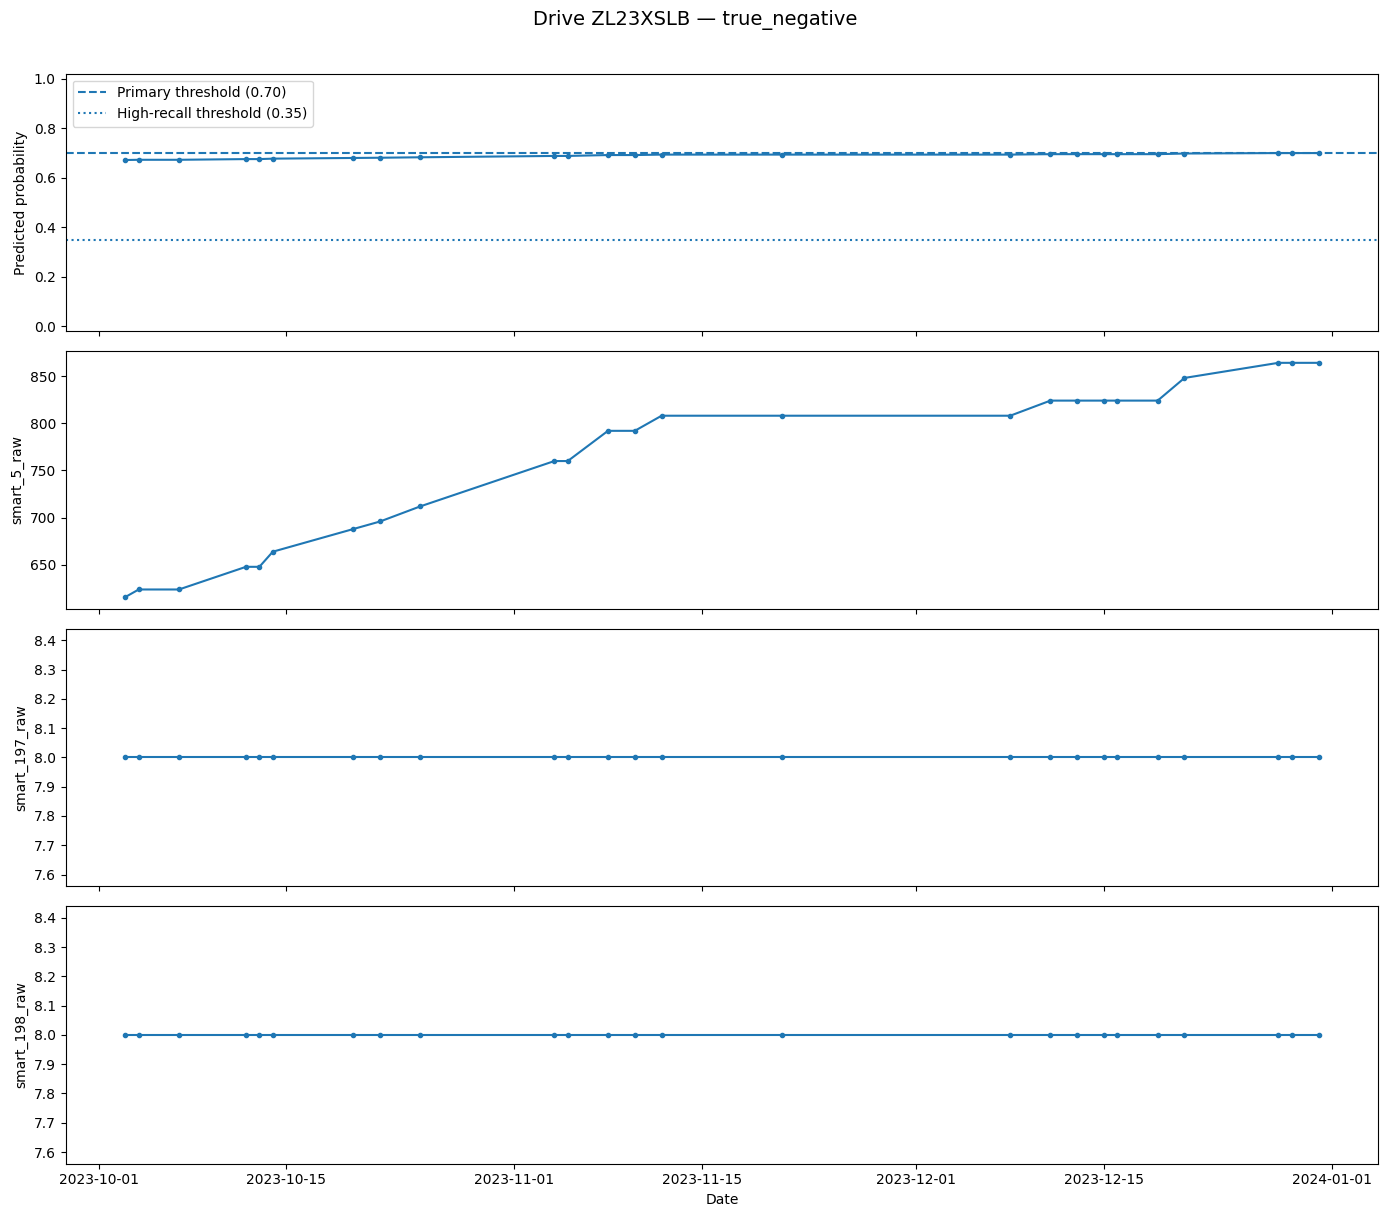

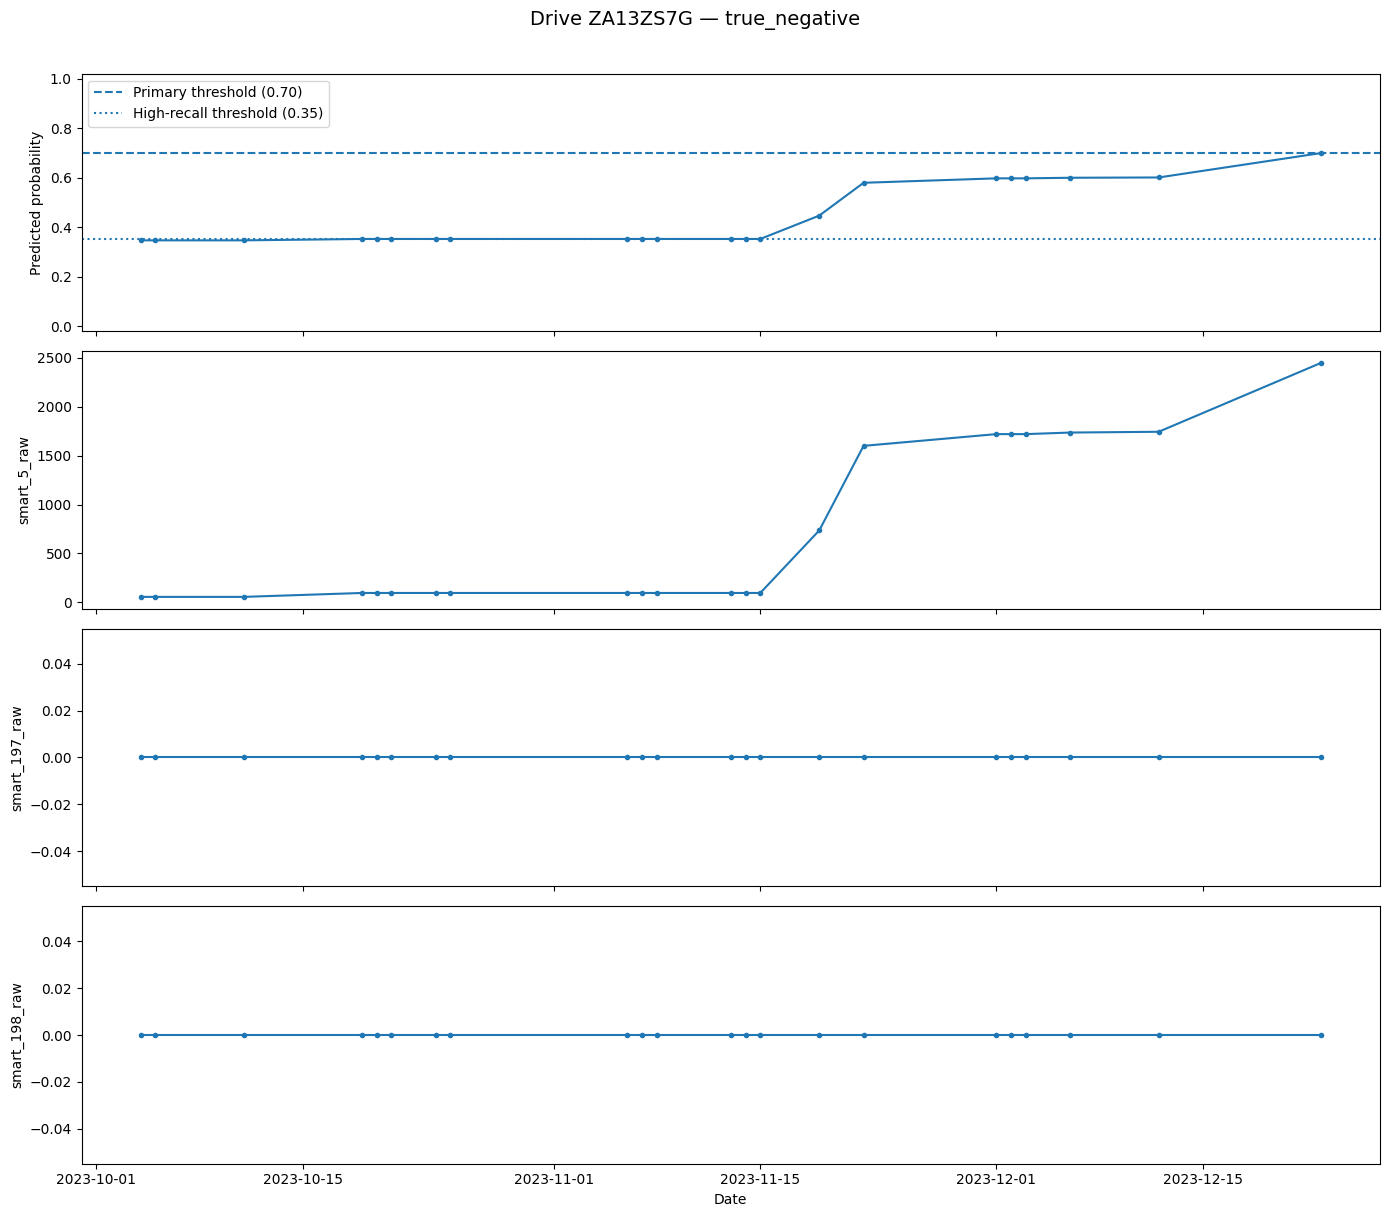

In [17]:
# ============================================================
# 17. Plot probability and SMART trajectories
# ============================================================

def plot_drive_trajectory(
    serial_number,
    rows,
    primary_threshold=PRIMARY_THRESHOLD,
    high_recall_threshold=HIGH_RECALL_THRESHOLD,
):
    drive_rows = (
        rows.loc[rows[SERIAL_COLUMN] == serial_number]
        .sort_values(DATE_COLUMN)
        .copy()
    )

    if drive_rows.empty:
        print(f"No rows found for drive {serial_number}.")
        return

    summary_row = drive_summary.loc[
        drive_summary[SERIAL_COLUMN] == serial_number
    ].iloc[0]

    error_group = summary_row["error_group"]
    failure_date = summary_row["failure_date"]

    fig, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(14, 12),
        sharex=True,
    )

    axes[0].plot(
        drive_rows[DATE_COLUMN],
        drive_rows[PROBABILITY_COLUMN],
        marker="o",
        markersize=3,
    )
    axes[0].axhline(
        primary_threshold,
        linestyle="--",
        label=f"Primary threshold ({primary_threshold:.2f})",
    )
    axes[0].axhline(
        high_recall_threshold,
        linestyle=":",
        label=f"High-recall threshold ({high_recall_threshold:.2f})",
    )
    axes[0].set_ylabel("Predicted probability")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].legend(loc="upper left")

    for axis, feature in zip(axes[1:], FEATURE_COLUMNS):
        axis.plot(
            drive_rows[DATE_COLUMN],
            drive_rows[feature],
            marker="o",
            markersize=3,
        )
        axis.set_ylabel(feature)

    if pd.notna(failure_date):
        for axis in axes:
            axis.axvline(
                failure_date,
                linestyle="--",
                linewidth=1.5,
            )

    axes[-1].set_xlabel("Date")
    fig.suptitle(
        f"Drive {serial_number} — {error_group}",
        y=1.01,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


for error_group, serial_numbers in representative_serials.items():
    display(
        Markdown(
            f"### {error_group.replace('_', ' ').title()} examples"
        )
    )

    for serial_number in serial_numbers:
        plot_drive_trajectory(serial_number, analysis_rows)

## 10. Save analysis artifacts

The exported tables preserve the drive-level error classifications and the diagnostic summaries used for the project report and Notebook 06 feature-screening decisions.

In [18]:
# ============================================================
# 18. Save outputs
# ============================================================

drive_summary_path = OUTPUT_DIRECTORY / "error_analysis_drive_summary.csv"
missed_failure_path = OUTPUT_DIRECTORY / "missed_failure_analysis.csv"
false_positive_path = OUTPUT_DIRECTORY / "false_positive_analysis.csv"
feature_summary_path = OUTPUT_DIRECTORY / "feature_summary_by_error_group.csv"
representative_cases_path = OUTPUT_DIRECTORY / "representative_drive_cases.csv"

drive_summary.to_csv(drive_summary_path, index=False)
missed_failures.to_csv(missed_failure_path, index=False)
false_positives.to_csv(false_positive_path, index=False)
feature_group_summary.to_csv(feature_summary_path, index=False)
representative_cases.to_csv(representative_cases_path, index=False)

saved_paths = [
    drive_summary_path,
    missed_failure_path,
    false_positive_path,
    feature_summary_path,
    representative_cases_path,
]

if model_error_counts is not None:
    model_error_path = OUTPUT_DIRECTORY / "model_error_analysis.csv"
    model_error_counts.to_csv(model_error_path, index=False)
    saved_paths.append(model_error_path)

print("Saved outputs:")
for path in saved_paths:
    print("  -", path)

Saved outputs:
  - /kaggle/working/error_analysis_drive_summary.csv
  - /kaggle/working/missed_failure_analysis.csv
  - /kaggle/working/false_positive_analysis.csv
  - /kaggle/working/feature_summary_by_error_group.csv
  - /kaggle/working/representative_drive_cases.csv
  - /kaggle/working/model_error_analysis.csv


## 11. Reproduction check against the authoritative historical run

This is a cleaned version of an experiment that was already completed. Therefore the goal is **reproduction, not re-optimization**.

The check below compares the new run with the headline counts from the authoritative Notebook 05 outputs. If the OOF and cleaned datasets are unchanged, these values should match. A mismatch is surfaced as a warning rather than silently accepted.

In [19]:
# ============================================================
# 19. Historical reproduction check
# ============================================================

REFERENCE_ERROR_COUNTS = {
    "true_positive": 152,
    "false_negative": 172,
    "false_positive": 1986,
    "true_negative": 278882,
}

REFERENCE_FAILURE_TIERS = {
    "detected_at_0.70": 152,
    "detected_only_at_0.35": 76,
    "missed_even_at_0.35": 96,
}

REFERENCE_MISS_PATTERNS = {
    "weak_signal_below_0.35": 69,
    "moderate_signal_0.35_to_0.60": 46,
    "short_history_under_7_days": 45,
    "near_miss_0.60_to_0.70": 12,
}

REFERENCE_FP_PATTERNS = {
    "repeated_nonpersistent_alerts": 1807,
    "single_day_spike": 83,
    "short_alert_burst": 76,
    "persistent_7_plus_day_run": 20,
}

REFERENCE_POSSIBLE_CENSORED = 1816

actual_error_counts = (
    drive_summary["error_group"].value_counts().to_dict()
)
actual_failure_tiers = (
    drive_summary.loc[
        drive_summary["is_failed"] == 1,
        "failure_detection_tier",
    ]
    .value_counts()
    .to_dict()
)
actual_miss_patterns = (
    missed_failures["miss_pattern"].value_counts().to_dict()
)
actual_fp_patterns = (
    false_positives["alert_pattern"].value_counts().to_dict()
)
actual_possible_censored = int(
    false_positives["possible_right_censoring"].sum()
)

checks = [
    {
        "check": "drive error counts",
        "matches_reference": actual_error_counts == REFERENCE_ERROR_COUNTS,
    },
    {
        "check": "failure detection tiers",
        "matches_reference": actual_failure_tiers == REFERENCE_FAILURE_TIERS,
    },
    {
        "check": "missed-failure patterns",
        "matches_reference": actual_miss_patterns == REFERENCE_MISS_PATTERNS,
    },
    {
        "check": "false-positive persistence patterns",
        "matches_reference": actual_fp_patterns == REFERENCE_FP_PATTERNS,
    },
    {
        "check": "possible right-censoring count",
        "matches_reference": actual_possible_censored == REFERENCE_POSSIBLE_CENSORED,
    },
]

reference_check = pd.DataFrame(checks)
display(reference_check)

print("Actual error counts:", actual_error_counts)
print("Actual failure tiers:", actual_failure_tiers)
print("Actual missed-failure patterns:", actual_miss_patterns)
print("Actual false-positive patterns:", actual_fp_patterns)
print("Actual possible-censoring count:", actual_possible_censored)

if reference_check["matches_reference"].all():
    print(
        "✓ CLEAN NOTEBOOK 05 REPRODUCES THE AUTHORITATIVE HISTORICAL COUNTS"
    )
else:
    warnings.warn(
        "Notebook 05 does not exactly reproduce the historical reference. "
        "Check whether the OOF artifact, cleaned dataset, or sample changed."
    )

,check,matches_reference
0,drive error counts,True
1,failure detection tiers,True
2,missed-failure patterns,True
3,false-positive persistence patterns,True
4,possible right-censoring count,True


Actual error counts: {'true_negative': 278882, 'false_positive': 1986, 'false_negative': 172, 'true_positive': 152}
Actual failure tiers: {'detected_at_0.70': 152, 'missed_even_at_0.35': 96, 'detected_only_at_0.35': 76}
Actual missed-failure patterns: {'weak_signal_below_0.35': 69, 'moderate_signal_0.35_to_0.60': 46, 'short_history_under_7_days': 45, 'near_miss_0.60_to_0.70': 12}
Actual false-positive patterns: {'repeated_nonpersistent_alerts': 1807, 'single_day_spike': 83, 'short_alert_burst': 76, 'persistent_7_plus_day_run': 20}
Actual possible-censoring count: 1816
✓ CLEAN NOTEBOOK 05 REPRODUCES THE AUTHORITATIVE HISTORICAL COUNTS


## 12. Evidence-based interpretation

The authoritative run supports four main conclusions:

1. **Threshold adjustment alone is insufficient.** At 0.70, 172 failed drives were missed. Only 12 were near misses in the 0.60–0.70 range, while 96 remained undetected even at 0.35.
2. **Many false negatives had weak signals in the current features.** The median value of all three selected SMART attributes was zero for the false-negative group, and their non-zero rates were much lower than for true positives.
3. **Short histories matter, but do not explain everything.** Forty-five missed failed drives had fewer than seven eligible observation days.
4. **False positives often looked genuinely abnormal.** The 1,986 alerted healthy drives had much stronger SMART abnormalities than true negatives, and most produced repeated alerts rather than isolated one-day spikes. Some were also flagged as potentially right-censored, but the available data cannot establish whether they later failed.

These findings motivate **targeted temporal and hardware-aware feature engineering** rather than indiscriminately adding many new predictors.

In [20]:
# ============================================================
# 20. Generate a run-specific conclusion
# ============================================================

confusion_lookup = dict(
    zip(
        confusion_counts["error_group"],
        confusion_counts["drive_count"],
    )
)

tp_count = int(confusion_lookup.get("true_positive", 0))
fn_count = int(confusion_lookup.get("false_negative", 0))
fp_count = int(confusion_lookup.get("false_positive", 0))
tn_count = int(confusion_lookup.get("true_negative", 0))

failed_total = tp_count + fn_count
healthy_total = fp_count + tn_count

drive_recall = tp_count / failed_total if failed_total else np.nan
drive_precision = (
    tp_count / (tp_count + fp_count)
    if (tp_count + fp_count)
    else np.nan
)

missed_even_low = int(
    (
        drive_summary["failure_detection_tier"]
        == "missed_even_at_0.35"
    ).sum()
)

near_miss_count = int(
    (
        missed_failures["miss_pattern"]
        == "near_miss_0.60_to_0.70"
    ).sum()
)

short_history_count = int(
    (
        missed_failures["miss_pattern"]
        == "short_history_under_7_days"
    ).sum()
)

persistent_fp_count = int(
    (
        false_positives["alert_pattern"]
        == "persistent_7_plus_day_run"
    ).sum()
)

single_spike_fp_count = int(
    (
        false_positives["alert_pattern"]
        == "single_day_spike"
    ).sum()
)

possible_censored_count = int(
    false_positives["possible_right_censoring"].sum()
)

conclusion = f"""
## Error-analysis conclusion

At the primary drive-level threshold of **{PRIMARY_THRESHOLD:.2f}**, the
Logistic Regression baseline detected **{tp_count:,} of {failed_total:,}**
failed drives, corresponding to drive-level recall of **{drive_recall:.1%}**.
It alerted **{fp_count:,} healthy drives**, giving drive-level precision of
**{drive_precision:.1%}**.

Among the **{fn_count:,} missed failed drives**, **{near_miss_count:,}** were
near misses whose maximum pre-failure score reached at least 0.60, while
**{missed_even_low:,}** remained undetected even under the more sensitive
0.35 threshold. This is evidence that threshold adjustment alone cannot
recover a large fraction of the remaining failures. **{short_history_count:,}**
missed failed drives had fewer than seven eligible observation days, so limited
history also contributes to detectability.

The **{fp_count:,} false-positive healthy drives** were not homogeneous.
**{single_spike_fp_count:,}** had only a single alert day, whereas
**{persistent_fp_count:,}** sustained an alert for at least seven consecutive
days. **{possible_censored_count:,}** false-positive drives were last alerted
within seven days of their final observation and are flagged as potentially
right-censored; this is descriptive and does not establish that they later
failed.

### Next decision

Use these errors to test a small set of targeted hypotheses:

1. recent SMART change / slope;
2. rolling maxima or persistence;
3. time since first abnormal SMART observation;
4. drive-model information where appropriate.

Any new feature set must be evaluated with the same leakage-safe grouped OOF
procedure before threshold comparisons are revisited.
"""

display(Markdown(conclusion))


## Error-analysis conclusion

At the primary drive-level threshold of **0.70**, the
Logistic Regression baseline detected **152 of 324**
failed drives, corresponding to drive-level recall of **46.9%**.
It alerted **1,986 healthy drives**, giving drive-level precision of
**7.1%**.

Among the **172 missed failed drives**, **12** were
near misses whose maximum pre-failure score reached at least 0.60, while
**96** remained undetected even under the more sensitive
0.35 threshold. This is evidence that threshold adjustment alone cannot
recover a large fraction of the remaining failures. **45**
missed failed drives had fewer than seven eligible observation days, so limited
history also contributes to detectability.

The **1,986 false-positive healthy drives** were not homogeneous.
**83** had only a single alert day, whereas
**20** sustained an alert for at least seven consecutive
days. **1,816** false-positive drives were last alerted
within seven days of their final observation and are flagged as potentially
right-censored; this is descriptive and does not establish that they later
failed.

### Next decision

Use these errors to test a small set of targeted hypotheses:

1. recent SMART change / slope;
2. rolling maxima or persistence;
3. time since first abnormal SMART observation;
4. drive-model information where appropriate.

Any new feature set must be evaluated with the same leakage-safe grouped OOF
procedure before threshold comparisons are revisited.


## Final takeaway

Notebook 05 changes the project question from **“Which threshold should we use?”** to **“What information is the current model missing?”**

The historical evidence indicates that the baseline's remaining errors are not primarily a threshold-tuning problem. Missed failures frequently exhibit weak or sparse signals in the three selected raw SMART attributes, while many false positives show sustained degradation despite no recorded failure during the observation window.

That diagnosis is the motivation for Notebook 06: a controlled screen of a small number of temporal features, evaluated under the same leakage-safe framework rather than a broad feature-expansion exercise.